In [114]:
import plotly.io as pio

try:
    import kaleido
    pio.renderers.default = "png"
except ImportError:
    print("Install kaleido: pip install kaleido")
    pio.renderers.default = "svg"

# Force PNG rendering for GitHub compatibility
pio.renderers.default = "png"
pio.templates.default = "plotly_white"

# Set both template AND kaleido engine settings
for template in ["plotly", "plotly_white"]:
    pio.templates[template].layout.update(
        width=1800,
        height=800,
        font=dict(size=14),
        title_x=0.5,
        paper_bgcolor='#1e1e1e',
        plot_bgcolor='#1e1e1e',
        font_color='white'
    )

# Set PNG export settings
pio.kaleido.scope.default_width = 1800
pio.kaleido.scope.default_height = 800
pio.kaleido.scope.default_scale = 1

/tmp/ipykernel_113677/3627552138.py:27: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.


/tmp/ipykernel_113677/3627552138.py:28: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.


/tmp/ipykernel_113677/3627552138.py:29: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_scale instead.




In [115]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
holidays = pd.read_csv('holidays_events.csv')
oil = pd.read_csv('oil.csv')

In [116]:
sales = pd.concat([train, test], sort=True)
sales = sales.merge(stores, how="left", on='store_nbr')   
sales = sales.merge(oil, how="left", on='date')      
sales = sales.merge(transactions, how="left", on=['date','store_nbr'])  
sales = sales.merge(holidays,on='date',how='left')
sales = sales.rename(columns={'type_x' : 'store_type','type_y':'holiday_type'})

sales.date = pd.to_datetime(sales.date)
sales['year'] = sales['date'].dt.year
sales['month'] = sales['date'].dt.month
sales['week'] = sales['date'].dt.isocalendar().week
sales['quarter'] = sales['date'].dt.quarter
sales['day_of_week'] = sales['date'].dt.day_name()
sales.head()

,date,family,id,onpromotion,sales,store_nbr,city,state,store_type,cluster,...,holiday_type,locale,locale_name,description,transferred,year,month,week,quarter,day_of_week
0,2013-01-01,AUTOMOTIVE,0,0,0.0,1,Quito,Pichincha,D,13,...,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1,Tuesday
1,2013-01-01,BABY CARE,1,0,0.0,1,Quito,Pichincha,D,13,...,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1,Tuesday
2,2013-01-01,BEAUTY,2,0,0.0,1,Quito,Pichincha,D,13,...,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1,Tuesday
3,2013-01-01,BEVERAGES,3,0,0.0,1,Quito,Pichincha,D,13,...,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1,Tuesday
4,2013-01-01,BOOKS,4,0,0.0,1,Quito,Pichincha,D,13,...,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1,Tuesday


In [117]:
train['date'] = pd.to_datetime(train.date)
test['date'] = pd.to_datetime(test.date)
transactions['date'] = pd.to_datetime(transactions.date)
oil['date'] = pd.to_datetime(oil.date)

In [118]:
train

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [119]:
test

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [120]:
stores.head(10)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [121]:
transactions

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


In [122]:
holidays

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [123]:
oil

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


In [124]:
import plotly.express as px

store_sales = pd.merge(train.groupby(['date', 'store_nbr']).sales.sum().reset_index(), transactions, how='left')
store_sales

,date,store_nbr,sales,transactions
0,2013-01-01,1,0.000000,NaN
1,2013-01-01,2,0.000000,NaN
2,2013-01-01,3,0.000000,NaN
3,2013-01-01,4,0.000000,NaN
4,2013-01-01,5,0.000000,NaN
...,...,...,...,...
90931,2017-08-15,50,16879.121004,2804.0
90932,2017-08-15,51,20154.559000,1573.0
90933,2017-08-15,52,18600.046000,2255.0
90934,2017-08-15,53,8208.189000,932.0


In [125]:
store_sales[store_sales['date'] == '2013-01-01']

,date,store_nbr,sales,transactions
0,2013-01-01,1,0.000000,NaN
1,2013-01-01,2,0.000000,NaN
2,2013-01-01,3,0.000000,NaN
3,2013-01-01,4,0.000000,NaN
4,2013-01-01,5,0.000000,NaN
5,2013-01-01,6,0.000000,NaN
6,2013-01-01,7,0.000000,NaN
7,2013-01-01,8,0.000000,NaN
8,2013-01-01,9,0.000000,NaN
9,2013-01-01,10,0.000000,NaN


In [126]:
store_sales = store_sales[store_sales['date'] != '2013-01-01']

Spearman Correlation between Total Sales and Transaction: 
---------------------------------------------------------
store_nbr       0.080932
sales           1.000000
transactions    0.817459
Name: sales, dtype: float64


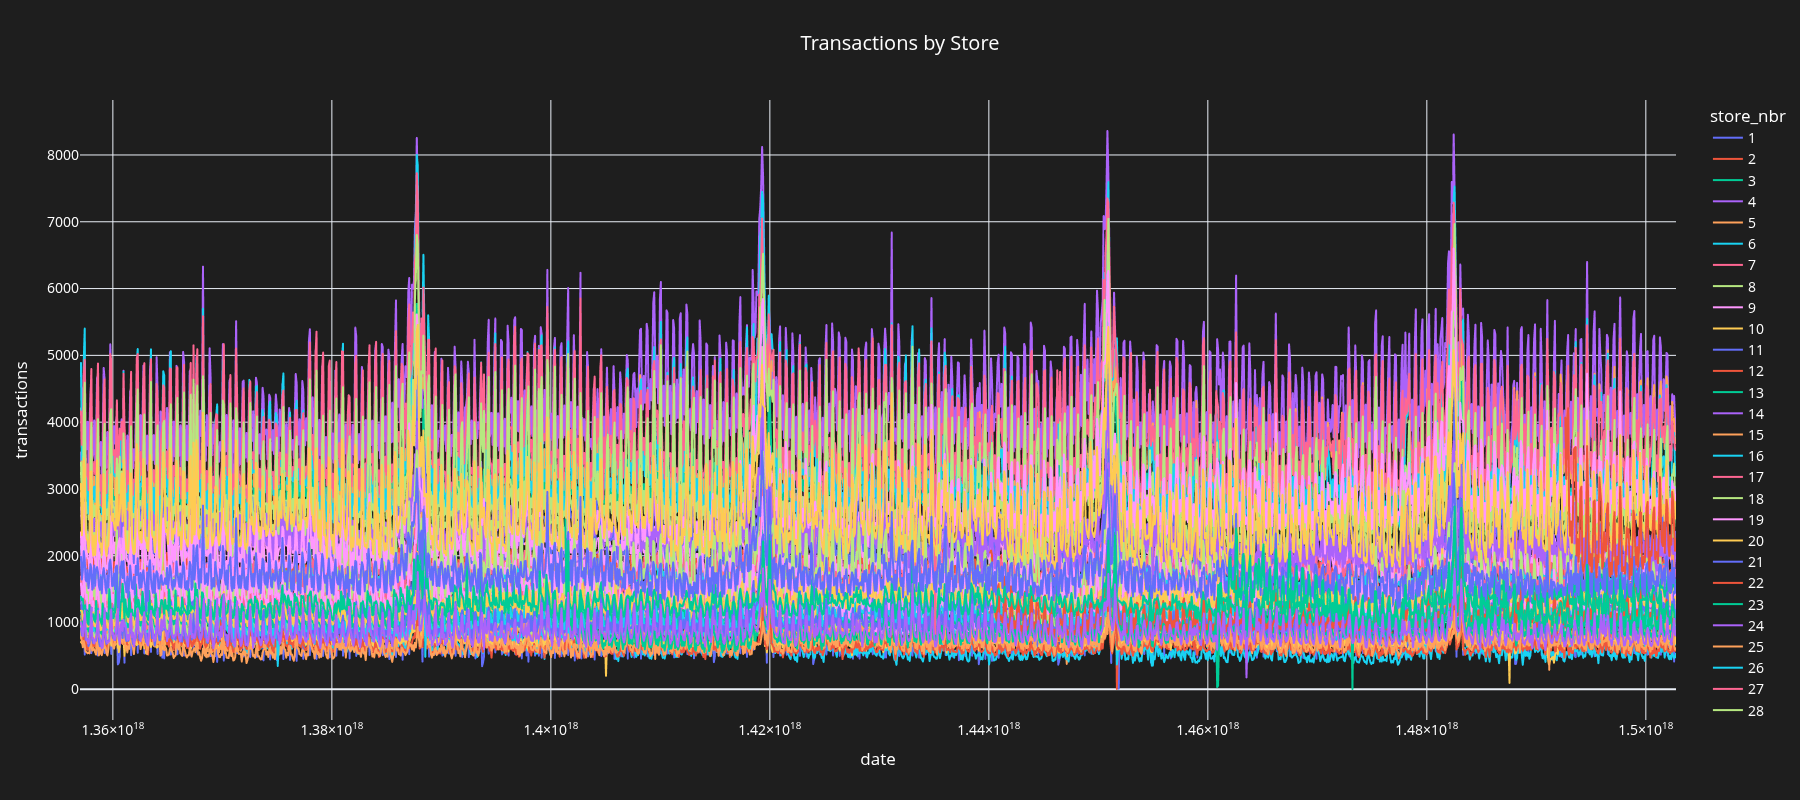

In [127]:
import plotly.express as px

corr_value = store_sales.corr('spearman').sales.drop('date')
print(f'Spearman Correlation between Total Sales and Transaction: \n{'-'*57}\n{corr_value}')

fig = px.line(transactions.sort_values(['store_nbr', 'date']), x='date', y='transactions',
        color='store_nbr', title='Transactions by Store')
fig.show()

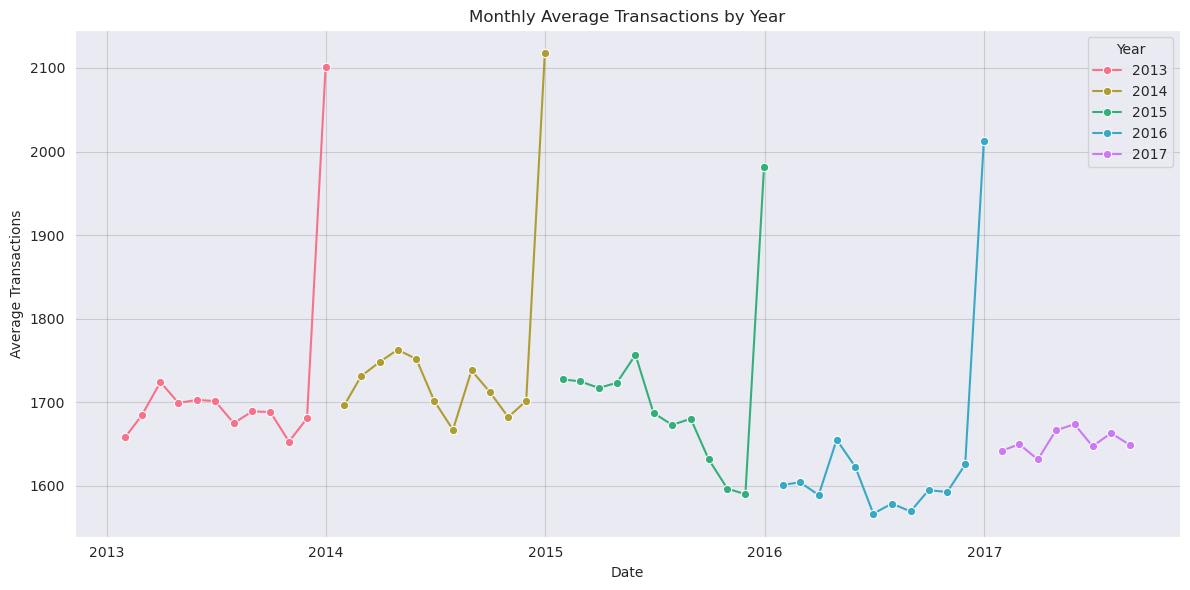

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
# plt.style.use('dark_background')

plt.figure(figsize=(12,6))

# Compute monthly average transactions, grouped by month end
monthly_avg_transactions = transactions.set_index('date').resample('ME').transactions.mean().reset_index()
monthly_avg_transactions['year'] = monthly_avg_transactions.date.dt.year

# Plot monthly average transactions with lines by year
color = sns.color_palette('husl', 5)
sns.lineplot(data=monthly_avg_transactions,
             x='date', y='transactions', hue='year', marker='o', palette=color)

plt.title('Monthly Average Transactions by Year')
plt.xlabel('Date')
plt.ylabel('Average Transactions')
plt.legend(title='Year')
plt.grid(True, color='grey', alpha=0.3)
plt.tight_layout()
plt.show()

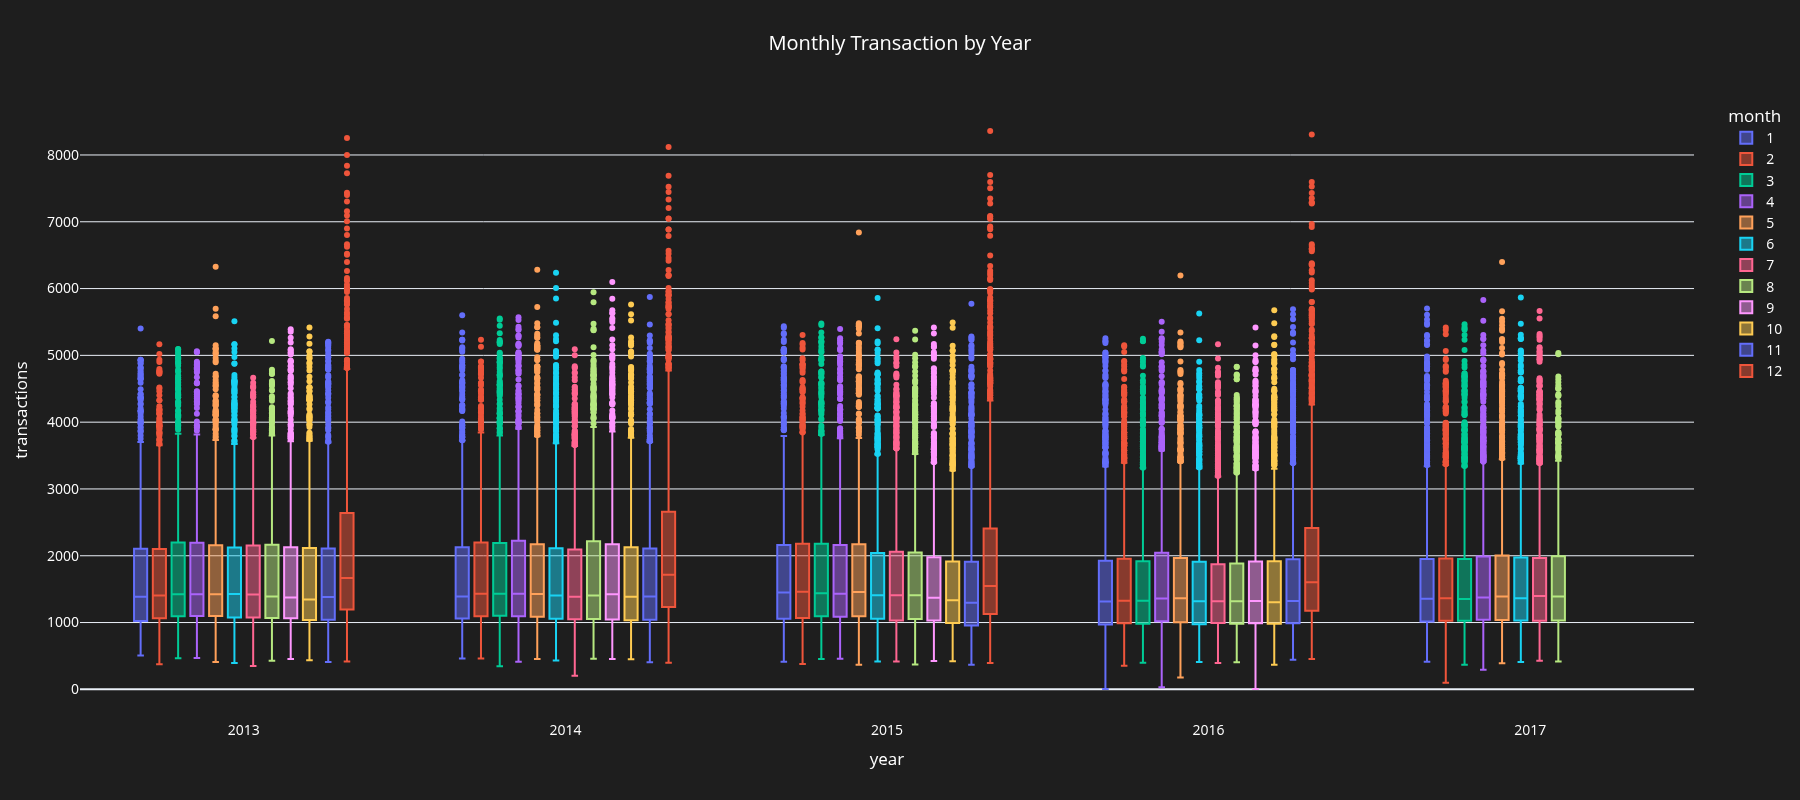

In [129]:
yearly_transactions = transactions.copy()
yearly_transactions['year'] = yearly_transactions.date.dt.year
yearly_transactions['month'] = yearly_transactions.date.dt.month

fig = px.box(yearly_transactions,
       x='year', y='transactions',
       color='month', title='Monthly Transaction by Year')
fig.show()

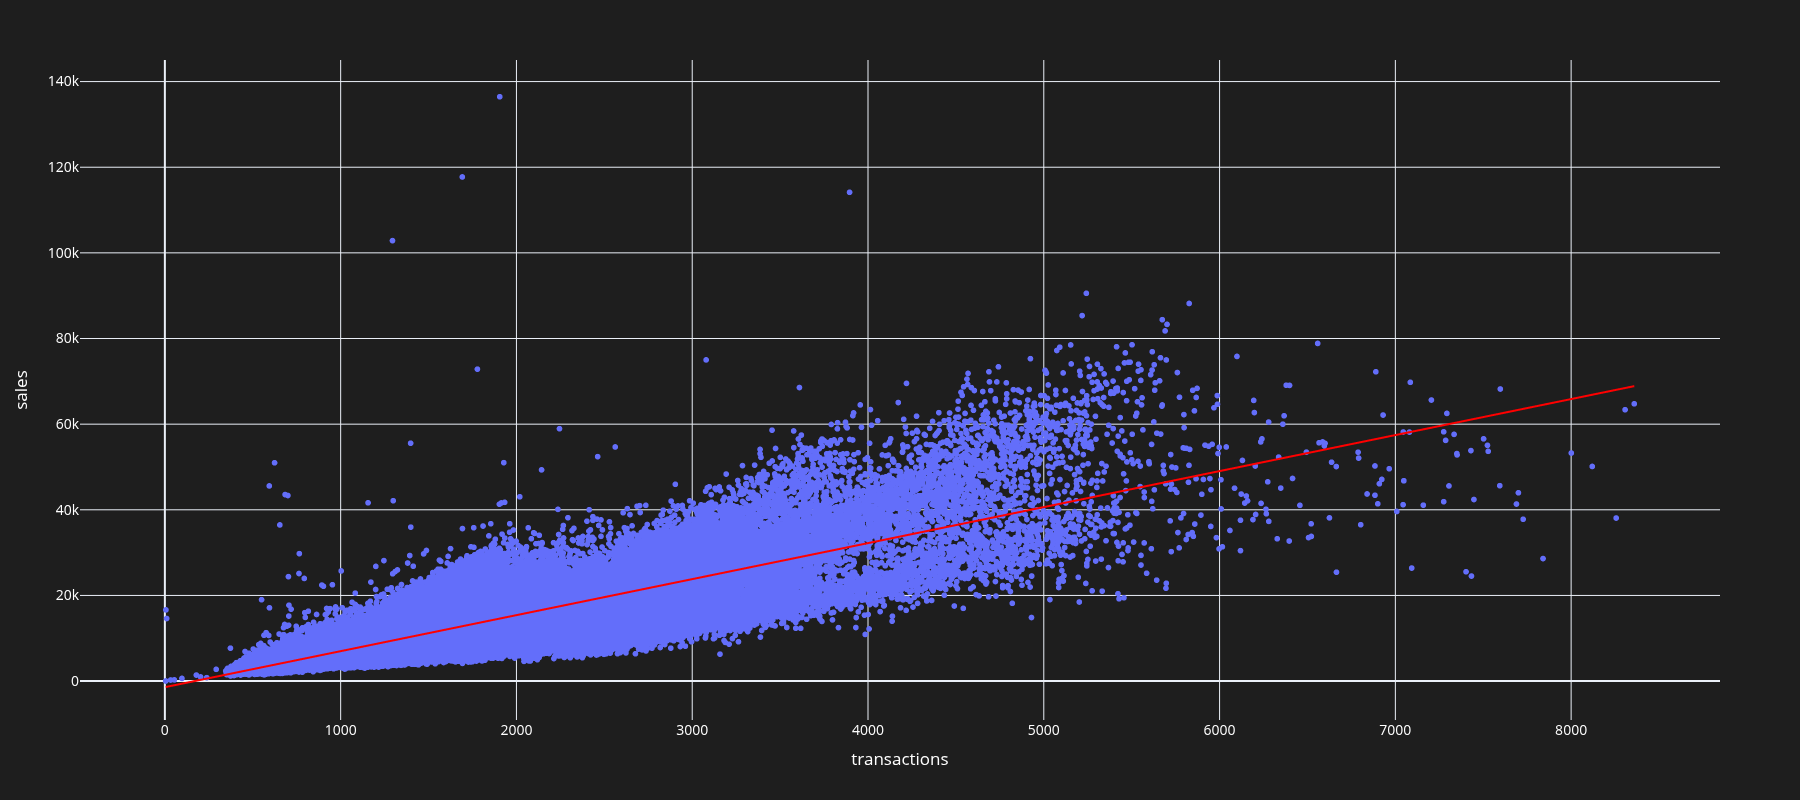

In [130]:
fig = px.scatter(store_sales, x='transactions', y='sales', trendline='ols', trendline_color_override='red')
fig.show()

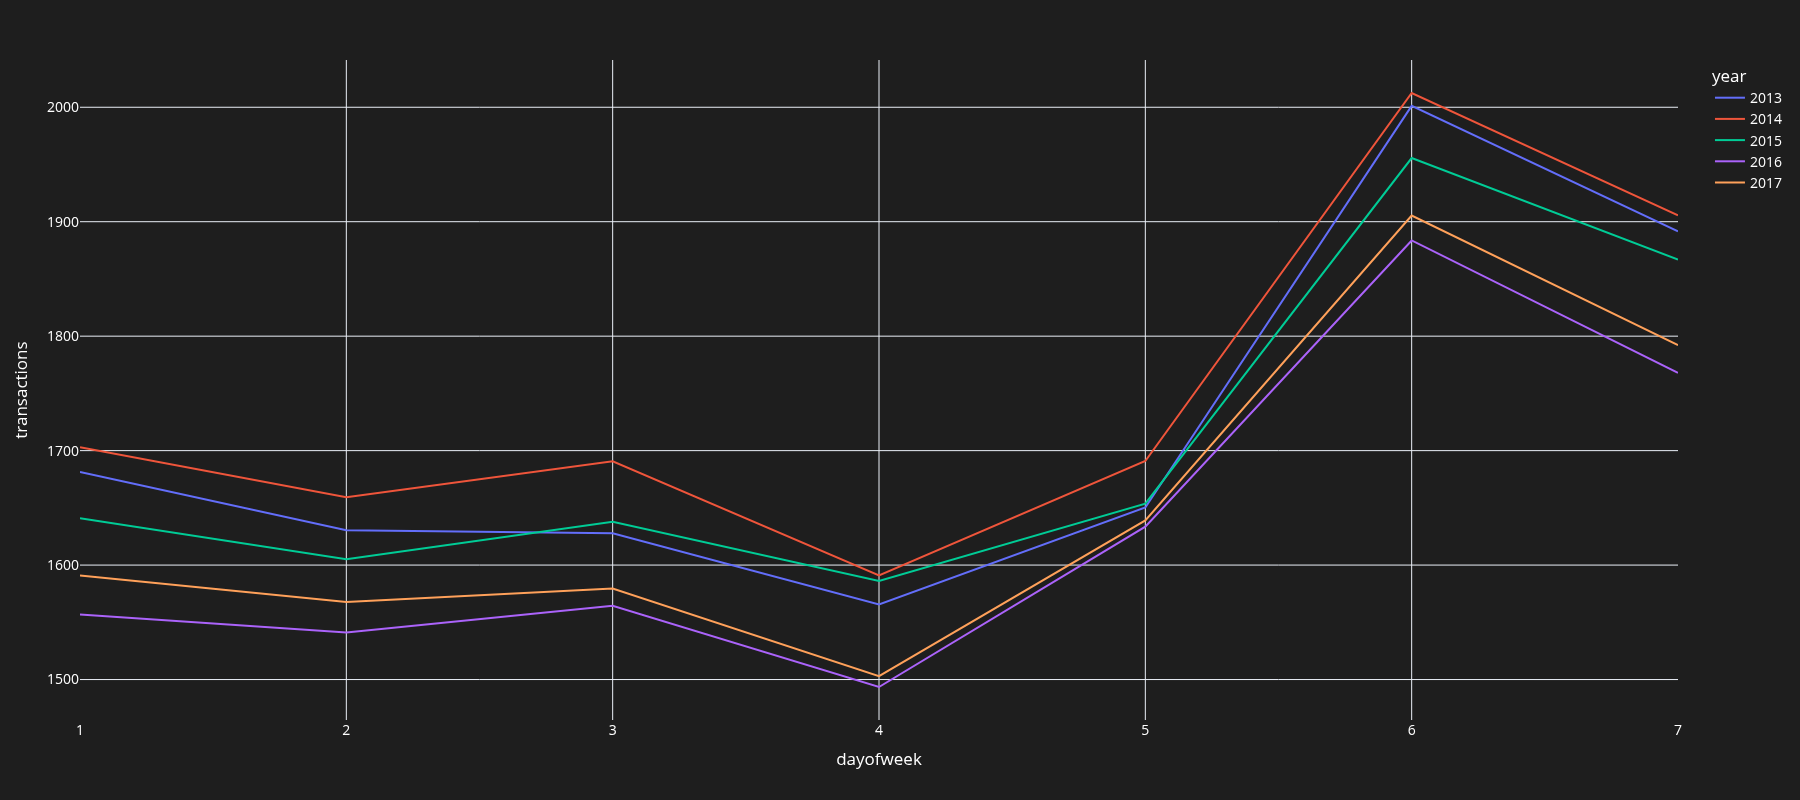

In [131]:
day_of_week_transactions = transactions.copy()
day_of_week_transactions['year'] = day_of_week_transactions.date.dt.year
day_of_week_transactions['dayofweek'] = day_of_week_transactions.date.dt.dayofweek+1
day_of_week_transactions = day_of_week_transactions.groupby(['year', 'dayofweek']).transactions.mean().reset_index()
fig = px.line(day_of_week_transactions,
        x='dayofweek', y='transactions',
        color='year')
fig.show()

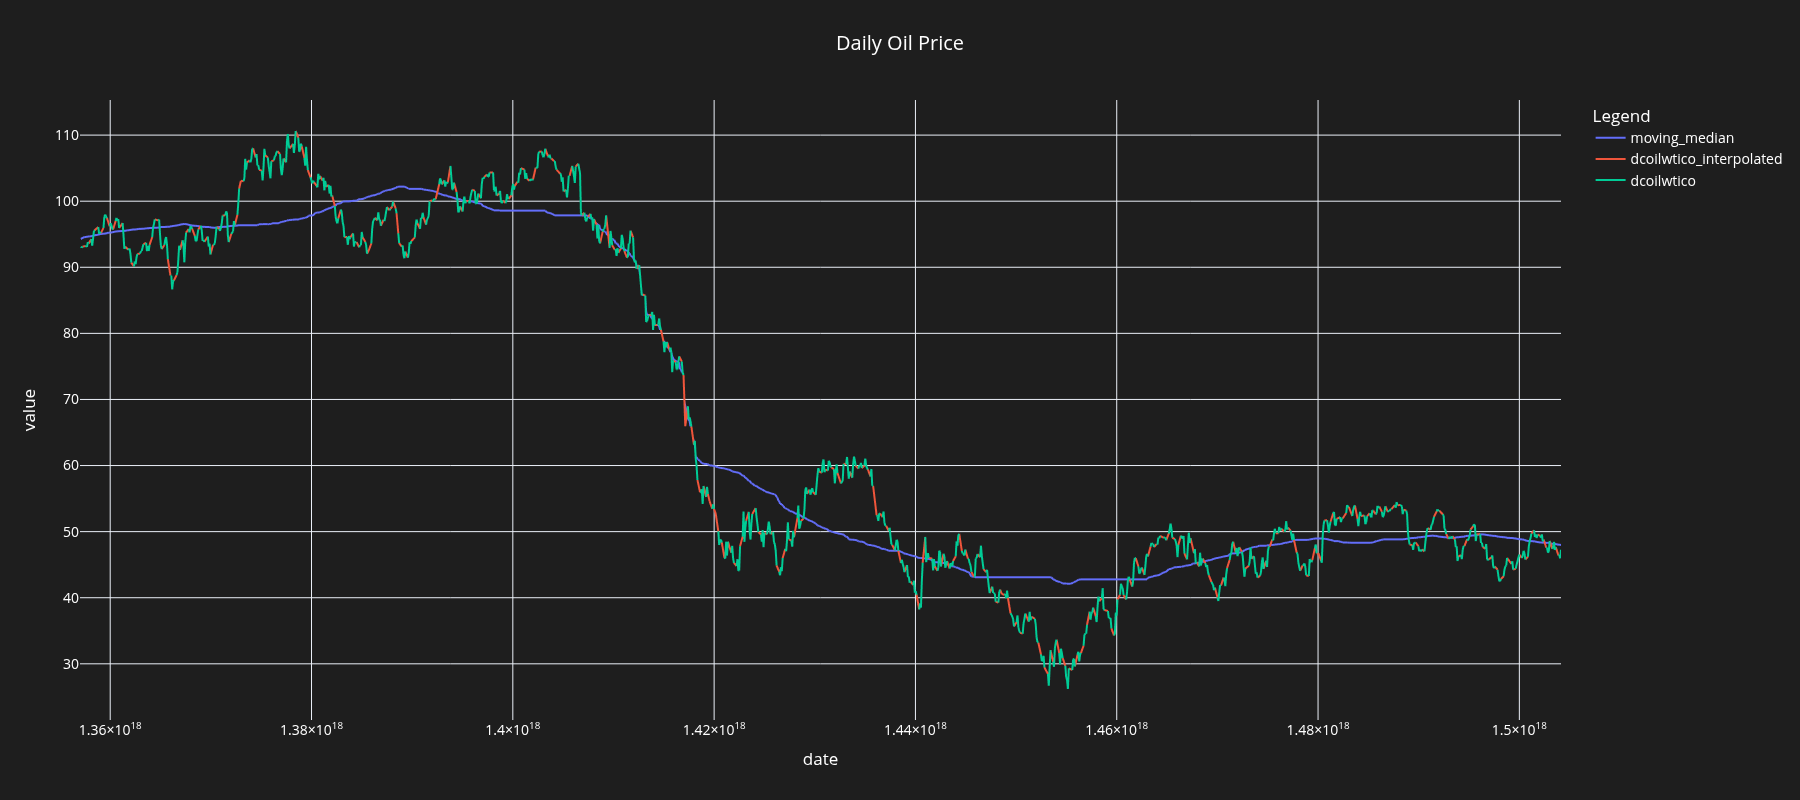

In [132]:
import numpy as np

daily_oil = oil.set_index('date').dcoilwtico.resample('D').sum().reset_index()
daily_oil['dcoilwtico'] = np.where(daily_oil['dcoilwtico'] == 0, np.nan, daily_oil['dcoilwtico'])
daily_oil['dcoilwtico_interpolated'] = daily_oil.dcoilwtico.interpolate()

# Assuming daily_oil is already created and interpolated
daily_oil['moving_median'] = daily_oil['dcoilwtico_interpolated'].rolling(
    window=365, center=True, min_periods=183).median()

oil_plot = daily_oil.melt(id_vars=['date']+list(oil.keys()[5:]), var_name='Legend')
fig = px.line(oil_plot.sort_values(['Legend', 'date'], ascending=[False, True]), x='date', y='value',
        color='Legend', title='Daily Oil Price')
fig.show()

Correlation with Daily Oil Price:
---------------------------------
sales          -0.30
transactions    0.04
Name: dcoilwtico_interpolated, dtype: float64


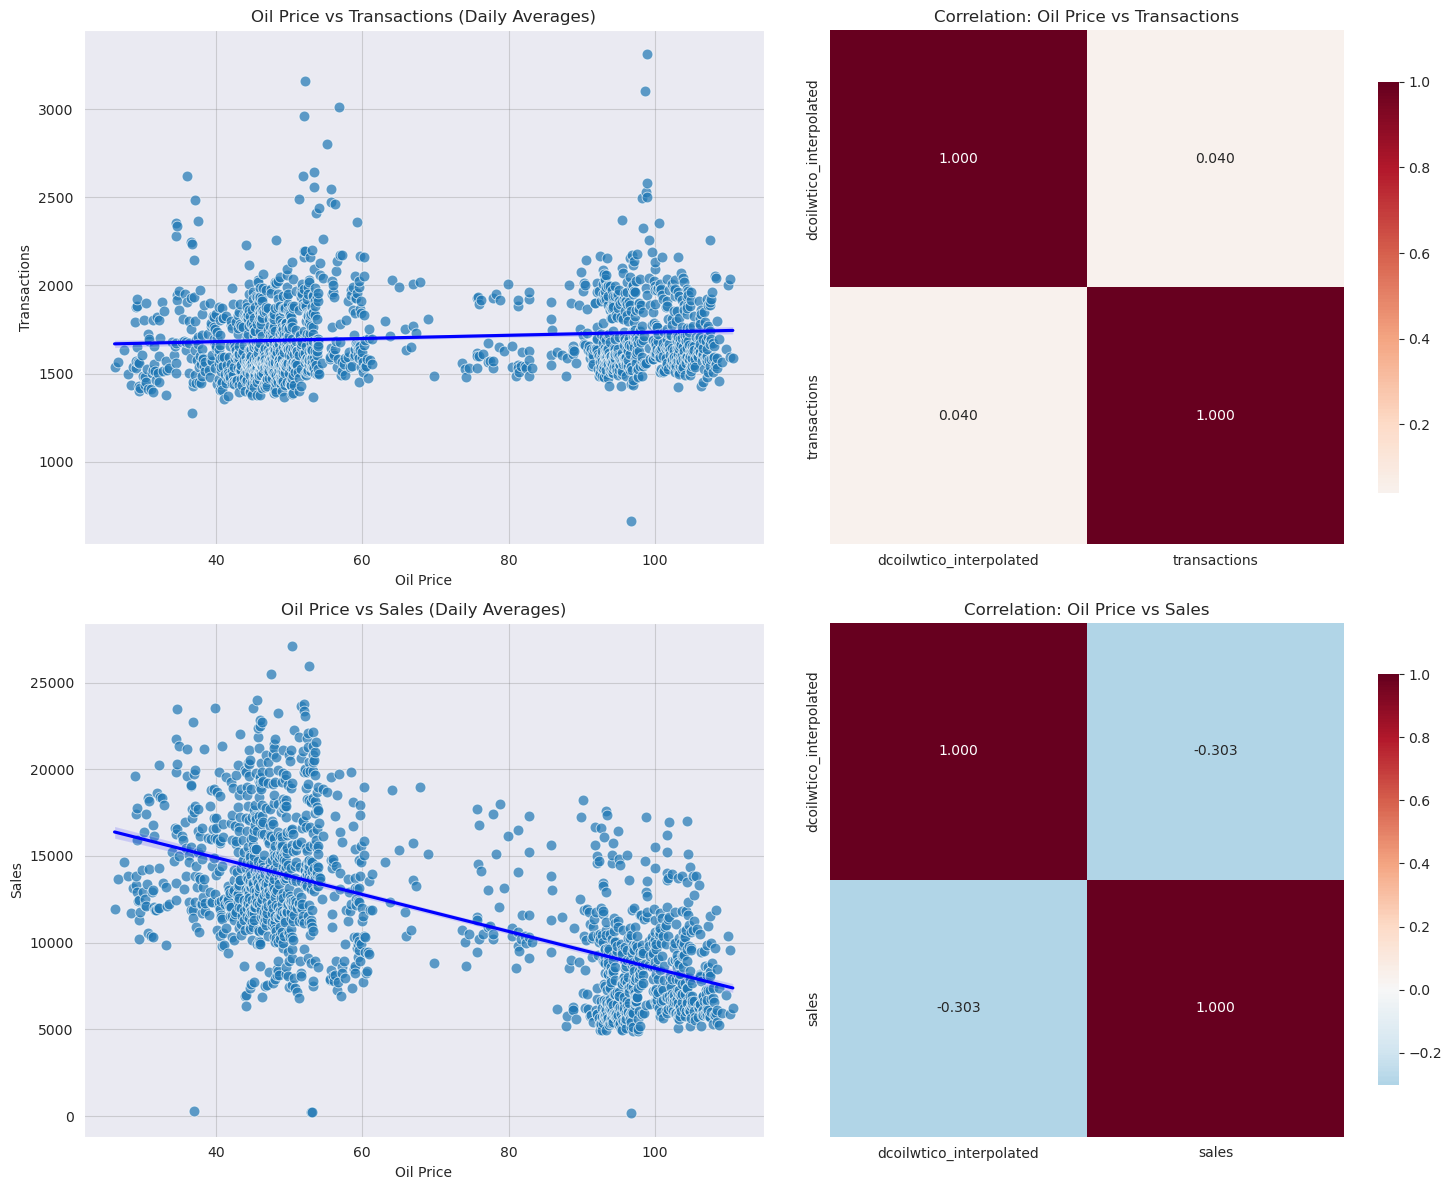

In [133]:
oil_with_daily_price = pd.merge(store_sales, daily_oil, how='left')
print('Correlation with Daily Oil Price:')
print('-'*33)
print(oil_with_daily_price.drop(['store_nbr', 'dcoilwtico'], axis=1).corr('spearman').dcoilwtico_interpolated.loc[['sales', 'transactions']].round(2))

# Aggregate data by oil price bins for cleaner visualization
# oil_with_daily_price['oil_price_bins'] = pd.cut(oil_with_daily_price['dcoilwtico_interpolated'], 
#                                                 bins=20, labels=False)

# Daily aggregated data
daily_agg = oil_with_daily_price.groupby('dcoilwtico_interpolated').agg({
    'sales': 'mean',
    'transactions': 'mean'
}).reset_index()

# Aggregated scatter plot with trend lines
sns.set_style('darkgrid')
# plt.style.use('dark_background')
fig, ax = plt.subplots(2, 2, figsize=(15, 12))
color = sns.color_palette('Spectral', as_cmap=True)

# Plot 1: Transactions vs Oil Price (top left)
sns.scatterplot(data=daily_agg, x='dcoilwtico_interpolated', y='transactions', 
                alpha=0.7, s=60, ax=ax[0,0])
sns.regplot(data=daily_agg, x='dcoilwtico_interpolated', y='transactions', 
            scatter=False, color='blue', ax=ax[0,0])
ax[0,0].set_title('Oil Price vs Transactions (Daily Averages)')
ax[0,0].set_xlabel('Oil Price')
ax[0,0].set_ylabel('Transactions')
ax[0,0].grid(True, color='grey', alpha=0.3)

# Transactions correlation heatmap (top right)
transactions_corr = oil_with_daily_price[['dcoilwtico_interpolated', 'transactions']].corr('spearman')
sns.heatmap(transactions_corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, ax=ax[0,1])
ax[0,1].set_title('Correlation: Oil Price vs Transactions')

# Plot 2: Sales vs Oil Price (bottom left)
sns.scatterplot(data=daily_agg, x='dcoilwtico_interpolated', y='sales', 
                alpha=0.7, s=60, ax=ax[1,0])
sns.regplot(data=daily_agg, x='dcoilwtico_interpolated', y='sales', 
            scatter=False, color='blue', ax=ax[1,0])
ax[1,0].set_title('Oil Price vs Sales (Daily Averages)')
ax[1,0].set_xlabel('Oil Price')
ax[1,0].set_ylabel('Sales')
ax[1,0].grid(True, color='grey', alpha=0.3)

# Sales correlation heatmap (bottom right)
sales_corr = oil_with_daily_price[['dcoilwtico_interpolated', 'sales']].corr('spearman')
sns.heatmap(sales_corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, ax=ax[1,1])
ax[1,1].set_title('Correlation: Oil Price vs Sales')

plt.tight_layout()
plt.show()

In [134]:
# daily_oil_with_family_sales = pd.merge(train.groupby(['date', 'family']).sales.sum().reset_index(), daily_oil.drop('dcoilwtico', axis=1), how='left')
# family = daily_oil_with_family_sales['family'].unique()
# family_corr = daily_oil_with_family_sales.groupby('family').corr('spearman').reset_index()
# family_corr = family_corr[family_corr.level_1 == "dcoilwtico_interpolated"][["family", "sales"]].sort_values("sales")

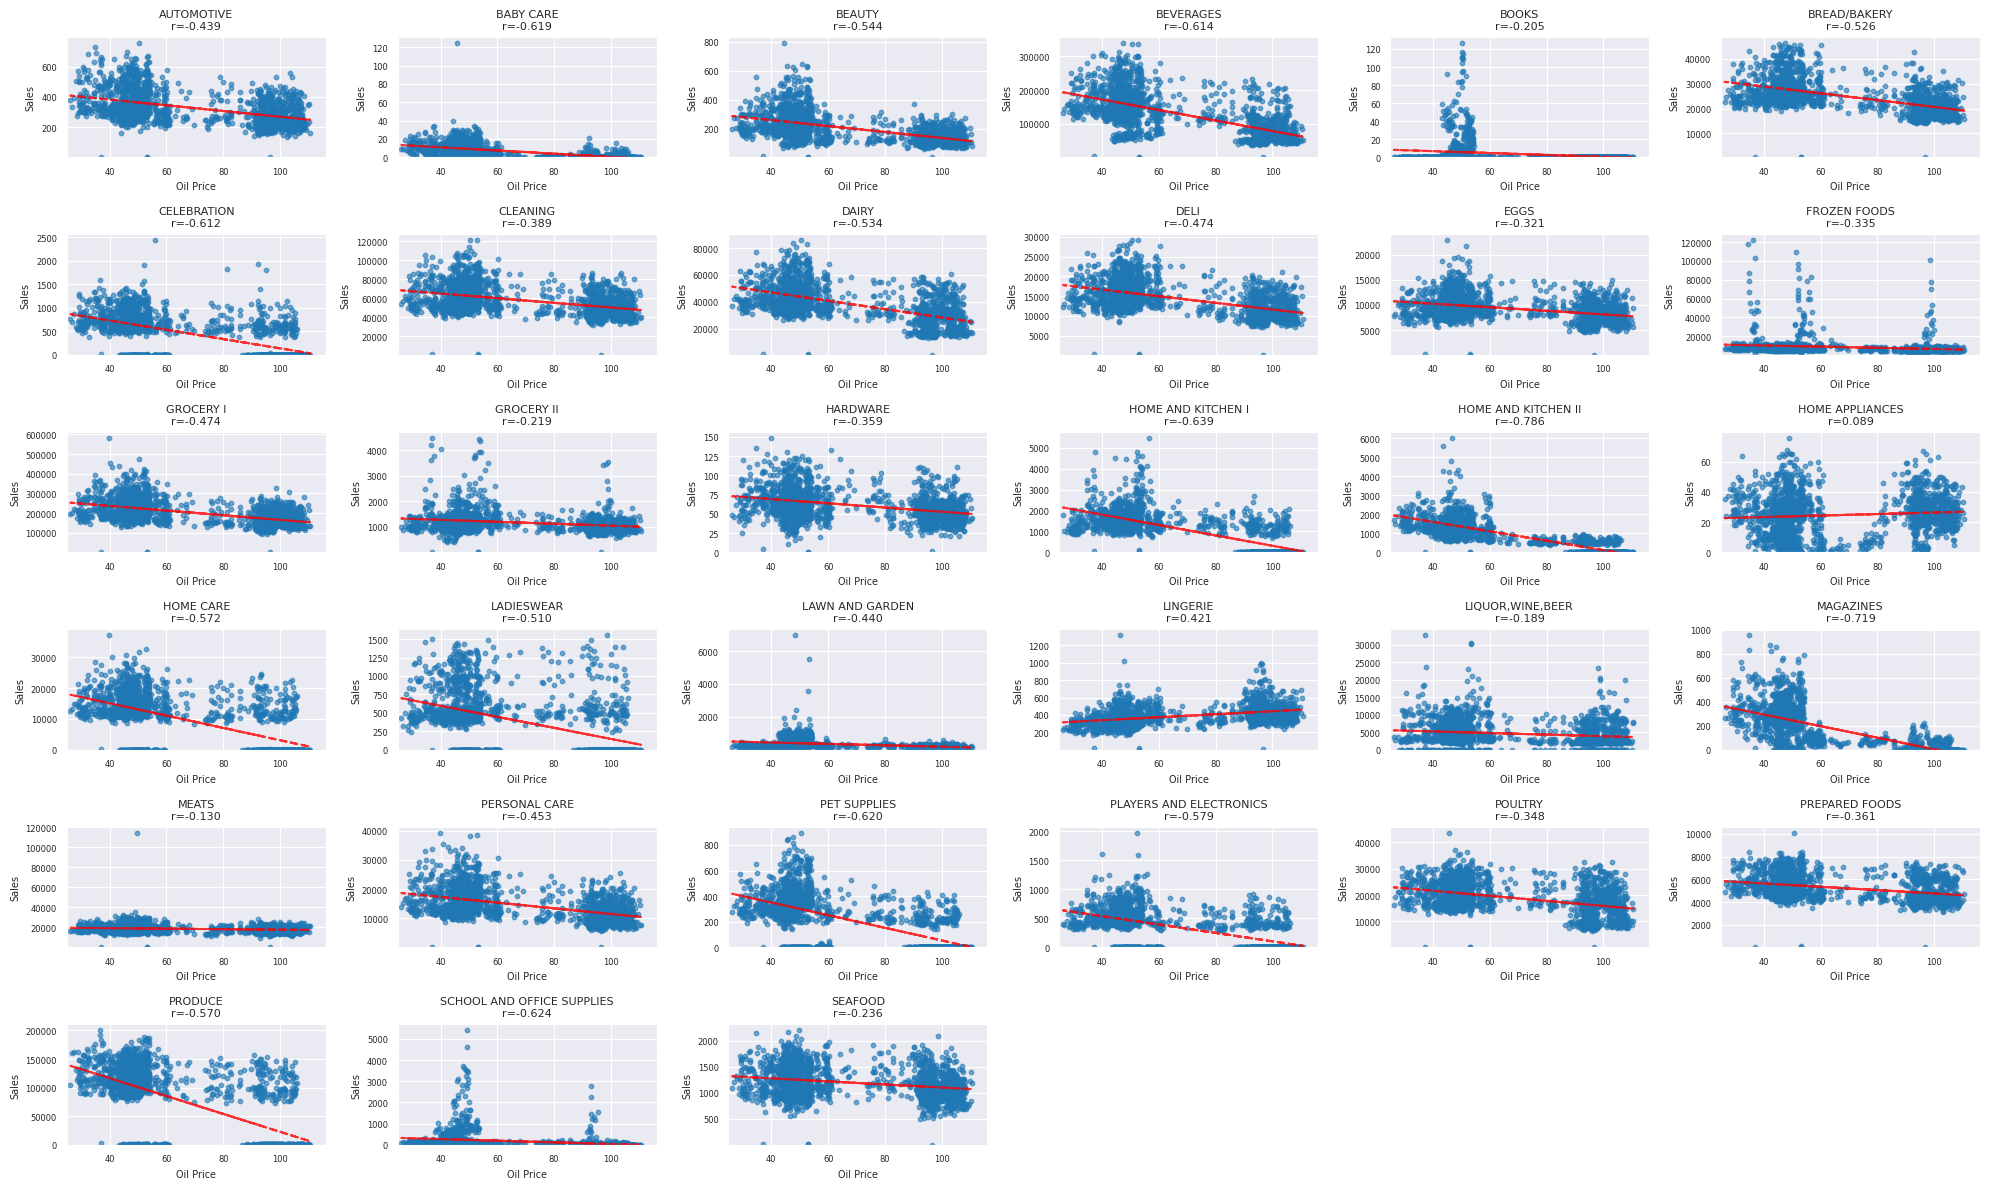

In [135]:
import math

daily_oil_with_family_sales = pd.merge(
    train.groupby(['date', 'family']).sales.sum().reset_index(), 
    daily_oil.drop('dcoilwtico', axis=1), 
    how='left'
)

family = daily_oil_with_family_sales['family'].unique()
family_corr = daily_oil_with_family_sales.groupby('family').corr('spearman').reset_index()
family_corr = family_corr[family_corr.level_1 == "dcoilwtico_interpolated"][["family", "sales"]].sort_values("sales")

n_cols = 6
n_rows = math.ceil(len(family) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
axes = axes.flatten()

for i, fam in enumerate(family):
    ax = axes[i]
    # Get data for this family
    family_data = daily_oil_with_family_sales[daily_oil_with_family_sales['family'] == fam]
    
    # Remove NaN values
    clean_data = family_data.dropna(subset=['dcoilwtico_interpolated', 'sales'])
    
    if len(clean_data) > 0:
        # Create scatter plot
        ax.scatter(clean_data['dcoilwtico_interpolated'], clean_data['sales'], 
                   alpha=0.6, s=10)
        
        # Add trend line only if we have enough data and sufficient variation
        if len(clean_data) > 2:  # Need at least 3 points
            try:
                # Check if there's variation in oil prices
                if clean_data['dcoilwtico_interpolated'].std() > 1e-10:
                    z = np.polyfit(clean_data['dcoilwtico_interpolated'], clean_data['sales'], 1)
                    p = np.poly1d(z)
                    ax.plot(clean_data['dcoilwtico_interpolated'], 
                            p(clean_data['dcoilwtico_interpolated']), "r--", alpha=0.8)
            except (np.linalg.LinAlgError, np.RankWarning):
                # Skip trend line if polyfit fails
                pass
    
    # Get correlation for title - handle case where family might not exist in correlation data
    try:
        corr_val = family_corr[family_corr['family'] == fam]['sales'].iloc[0]
        ax.set_title(f'{fam}\nr={corr_val:.3f}', fontsize=8)
    except (IndexError, KeyError):
        ax.set_title(f'{fam}\nr=N/A', fontsize=8)
    
    ax.set_xlabel('Oil Price', fontsize=7)
    ax.set_ylabel('Sales', fontsize=7)
    ax.tick_params(labelsize=6)
    
    # Set reasonable axis limits if data exists
    if len(clean_data) > 0:
        ax.set_xlim(clean_data['dcoilwtico_interpolated'].min() * 0.95, 
                   clean_data['dcoilwtico_interpolated'].max() * 1.05)
        ax.set_ylim(clean_data['sales'].min() * 0.95, 
                   clean_data['sales'].max() * 1.05)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

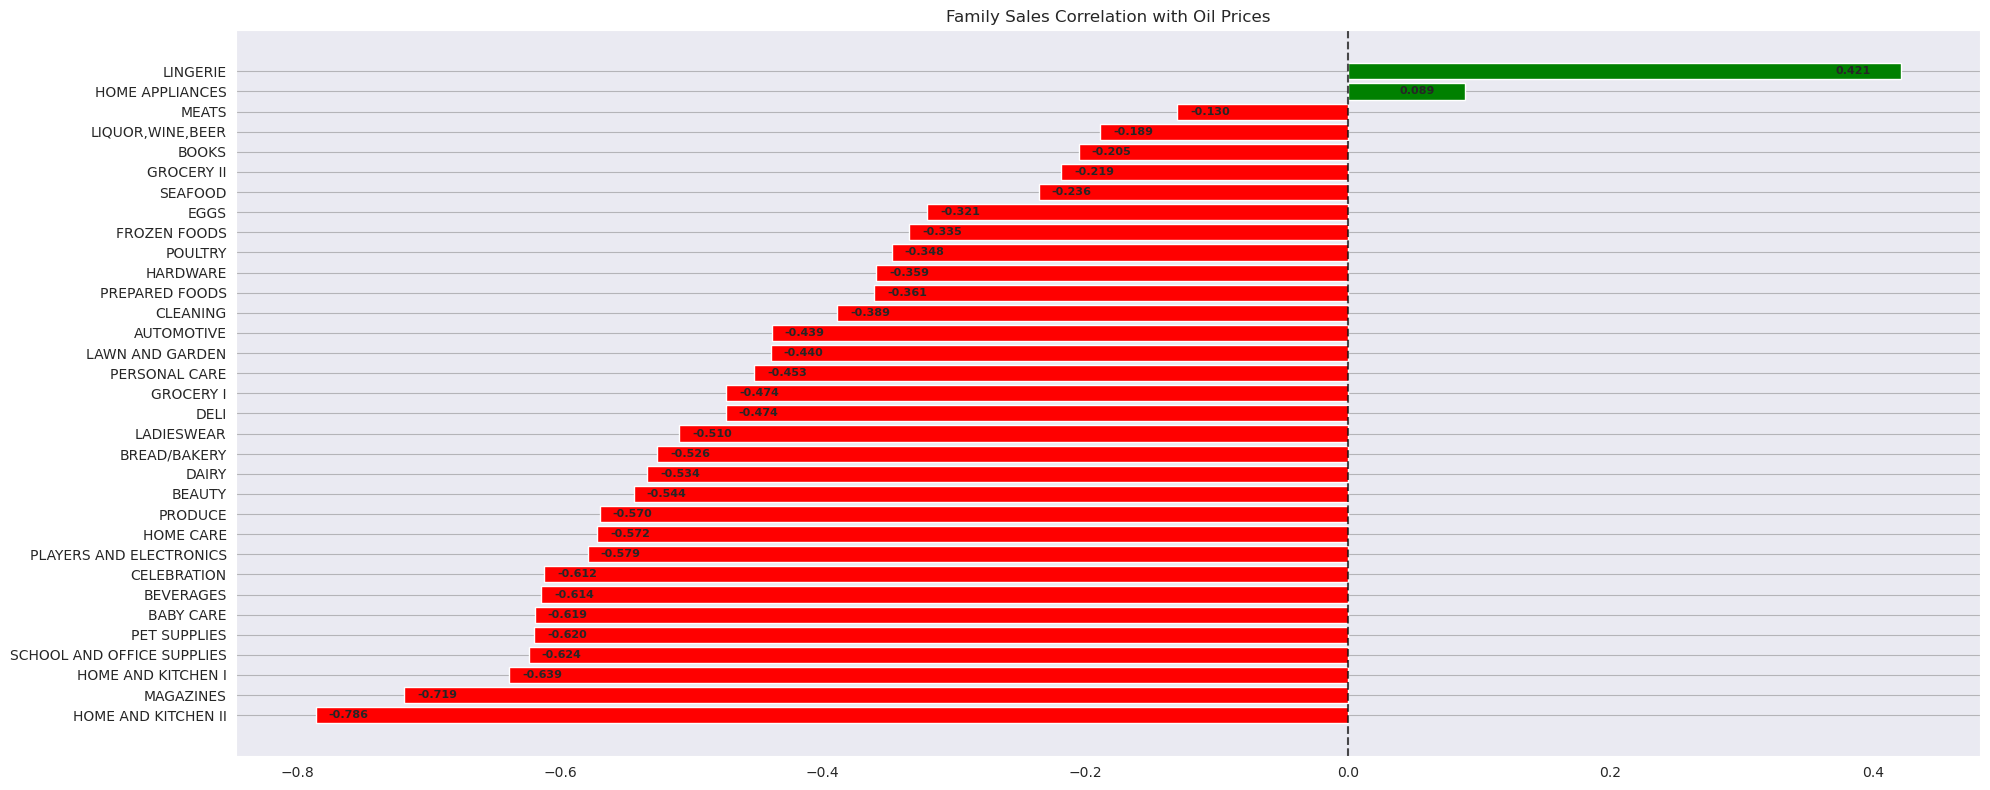

In [136]:
plt.figure(figsize=(20, 8))
color = ['red' if x < 0 else 'green' for x in family_corr['sales']]
plt.barh(range(len(family_corr)), family_corr['sales'], color=color)
plt.yticks(range(len(family_corr)), family_corr['family'])
plt.xlabel('')
plt.title('Family Sales Correlation with Oil Prices')

# Add correlation values as text
for i, (idx, row) in enumerate(family_corr.iterrows()):
    plt.text(row['sales'] - 0.05 if row['sales'] >= 0 else row['sales'] + 0.01, 
             i, f'{row["sales"]:.3f}', 
             va='center', fontweight='bold', fontsize=8)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.grid(axis='x', alpha=0.0, color='grey')
plt.grid(axis='y', alpha=0.5, color='grey')
plt.tight_layout()
plt.show()

/tmp/ipykernel_113677/2119624823.py:11: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/tmp/ipykernel_113677/2119624823.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the

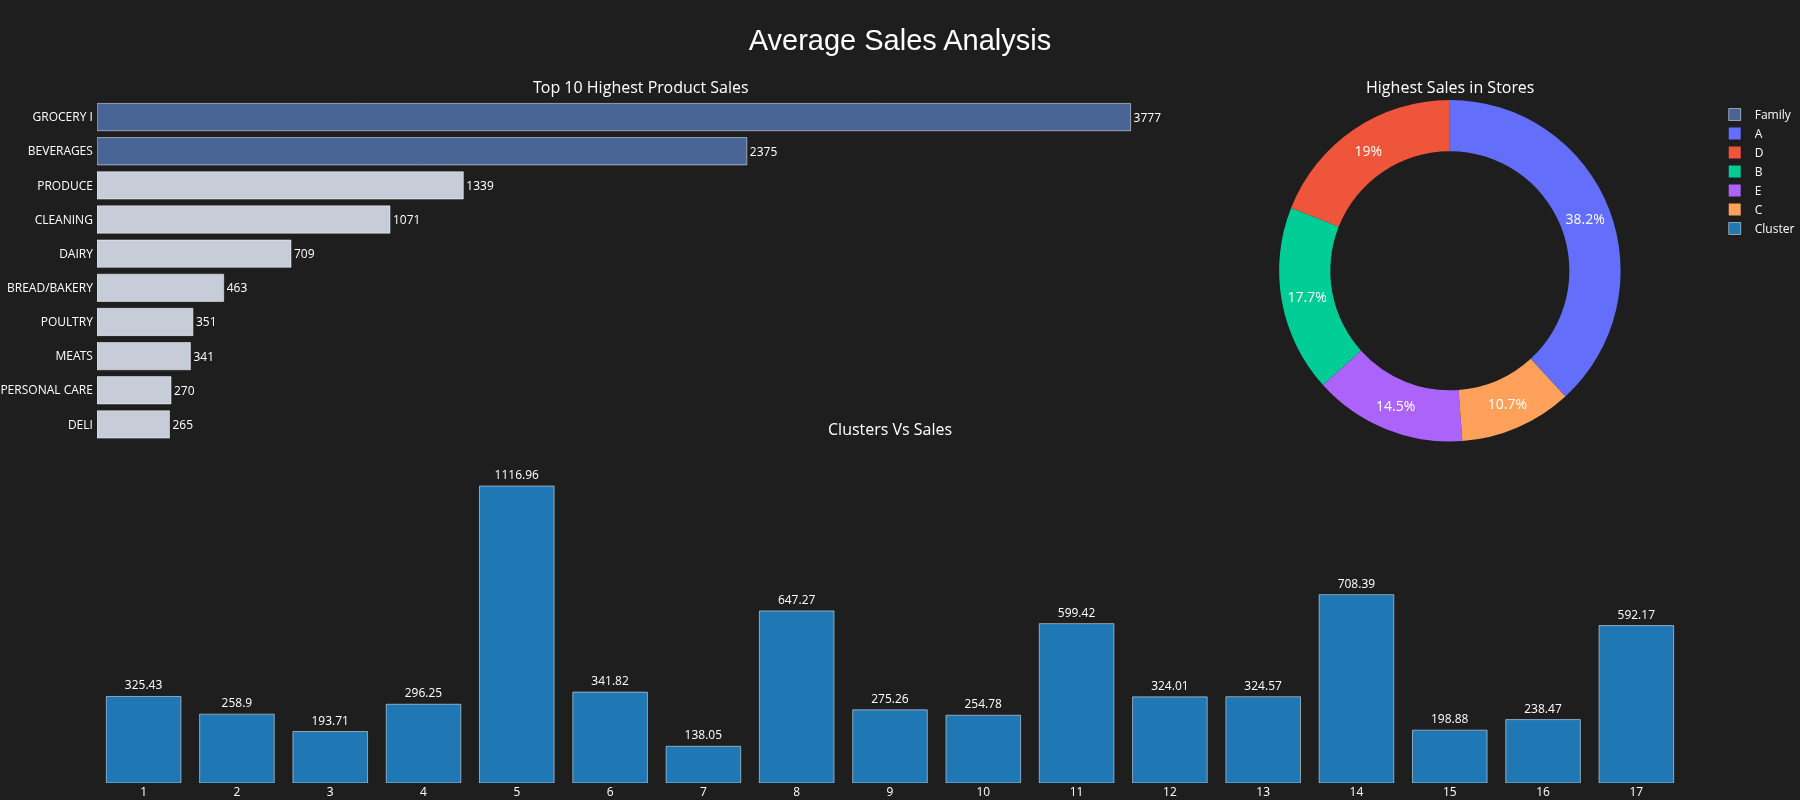

In [137]:
from plotly.subplots import make_subplots
import plotly.graph_objs as go

# data
df_st_sa = sales[:train.shape[0]].groupby('store_type').agg({"sales" : "mean"}).reset_index().sort_values(by='sales', ascending=False)
df_fa_sa = sales[:train.shape[0]].groupby('family').agg({"sales" : "mean"}).reset_index().sort_values(by='sales', ascending=False)[:10]
df_cl_sa = sales[:train.shape[0]].groupby('cluster').agg({"sales" : "mean"}).reset_index() 

# chart color
df_fa_sa['color'] = '#496595'
df_fa_sa['color'][2:] = '#c6ccd8'
df_cl_sa['color'] = '#1f77b4'  # Better contrast for dark theme

# chart
fig = make_subplots(rows=2, cols=2, 
                    specs=[[{"type": "bar"}, {"type": "pie"}],
                           [{"colspan": 2}, None]],
                    column_widths=[0.7, 0.3], vertical_spacing=0, horizontal_spacing=0.02,
                    subplot_titles=("Top 10 Highest Product Sales", "Highest Sales in Stores", "Clusters Vs Sales"))

# Top 10 highest product sales bars with values
fig.add_trace(go.Bar(
    x=df_fa_sa['sales'], y=df_fa_sa['family'], marker=dict(color=df_fa_sa['color']),
    name='Family', orientation='h',
    text=round(df_fa_sa['sales']), textposition='outside',
    textfont=dict(color='white', size=12)  # White text for dark background
), row=1, col=1)

# Pie chart with percentages inside
fig.add_trace(go.Pie(
    values=df_st_sa['sales'], labels=df_st_sa['store_type'], name='Store type',
    hole=0.7,
    hoverinfo='label+percent+value', textinfo='percent',
    textposition='inside',
    textfont=dict(color='white', size=14)  # White text for pie chart
), row=1, col=2)

# Clusters vs sales bar chart with values above bars
fig.add_trace(go.Bar(
    x=df_cl_sa['cluster'], y=df_cl_sa['sales'], 
    name='Cluster', marker=dict(color=df_cl_sa['color']),
    text=df_cl_sa['sales'].round(2), textposition='outside',
    textfont=dict(color='white', size=12)  # White text for dark background
), row=2, col=1)

# styling
fig.update_yaxes(showgrid=False, ticksuffix=' ', categoryorder='total ascending', row=1, col=1)
fig.update_xaxes(visible=False, row=1, col=1)
fig.update_xaxes(tickmode = 'array', tickvals=df_cl_sa.cluster, ticktext=[i for i in range(1,17)], row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=1)
# Fix y-axis range for cluster chart to show text above bars
max_cluster_sales = df_cl_sa['sales'].max()
fig.update_yaxes(range=[0, max_cluster_sales * 1.15], row=2, col=1)

fig.update_layout(
    height=500, bargap=0.2,
    margin=dict(b=0,r=20,l=20), xaxis=dict(tickmode='linear'),
    title_text="Average Sales Analysis",
    title_font=dict(size=29, color='white', family="Lato, sans-serif"),  # White title
    font=dict(color='white', size=12),  # White font for all text
    paper_bgcolor='#1e1e1e',  # Dark background
    plot_bgcolor='#1e1e1e',   # Dark plot area
    hoverlabel=dict(bgcolor="#333333", font_size=10, font_family="Lato, sans-serif"),
    showlegend=True
)

# Update subplot title colors
fig.update_annotations(font_color="white")

fig.show()

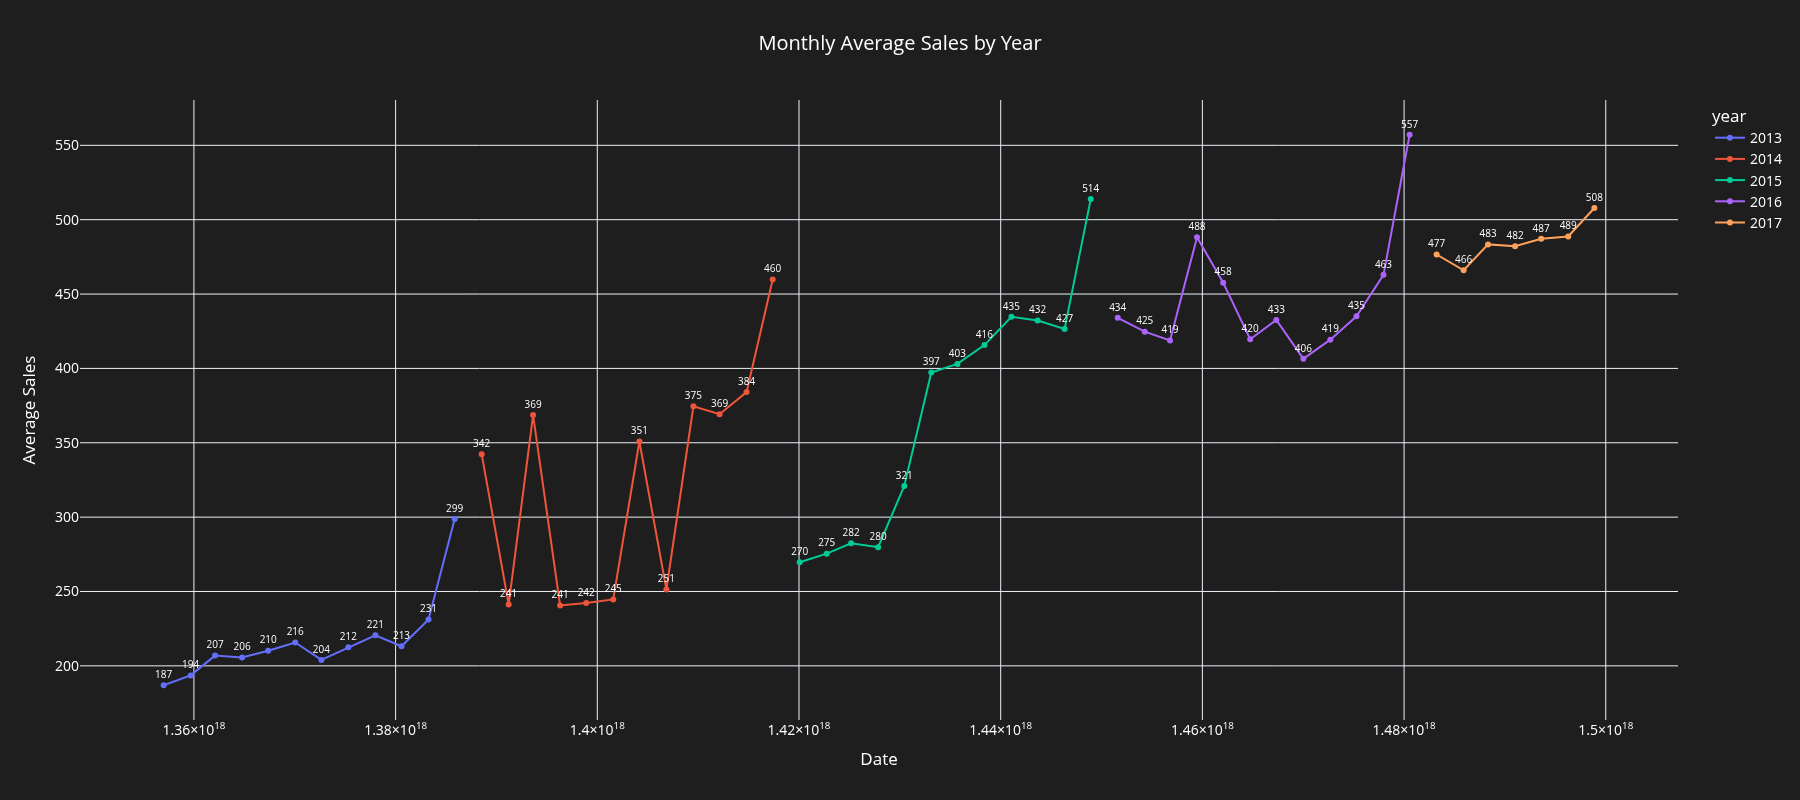

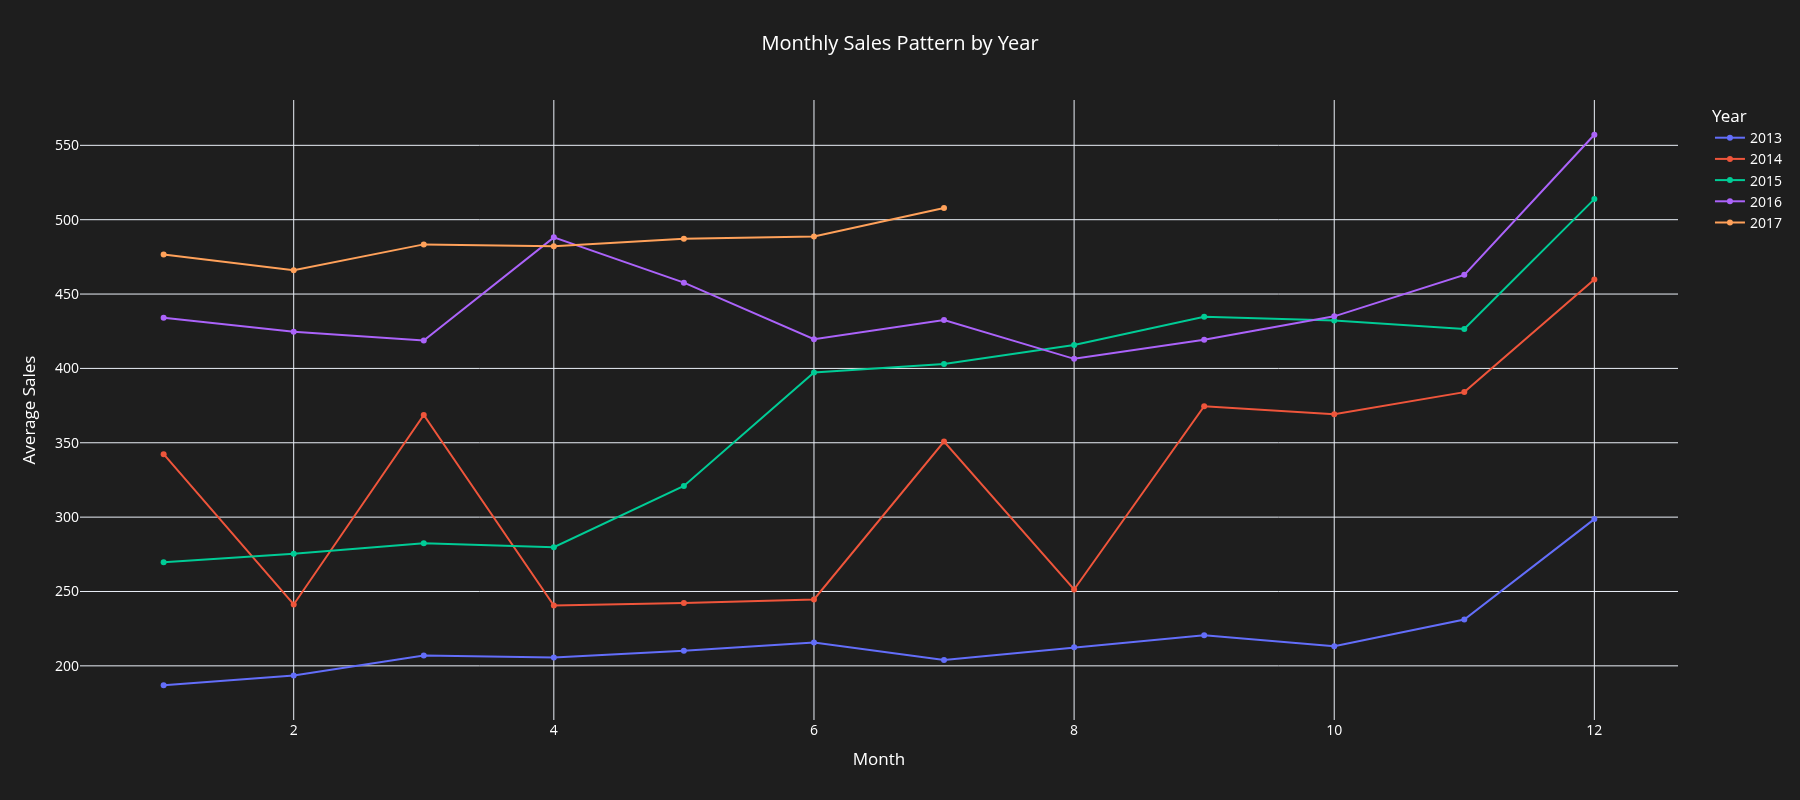

In [138]:
# Much simpler data preparation
sales_clean = sales[:train.shape[0]].copy()
sales_clean['date'] = pd.to_datetime(sales_clean[['year', 'month']].assign(day=1))

# Group by month-year and calculate mean
monthly_sales = sales_clean.groupby(['year', 'month'])['sales'].mean().reset_index()
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))

# Create the plot with values
fig = px.line(monthly_sales, 
              x='date', 
              y='sales', 
              color='year',
              markers=True,
              title='Monthly Average Sales by Year')

# Add values on hover and customize
fig.update_traces(
    mode='lines+markers+text',
    textposition='top center',
    texttemplate='%{y:.0f}',
    textfont_size=10
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Average Sales',
    hovermode='x unified',
    font=dict(color='white')
)

fig.show()

# Alternative: Even simpler with pivot for better visualization
pivot_data = monthly_sales.pivot(index='month', columns='year', values='sales')

fig2 = px.line(pivot_data, 
               title='Monthly Sales Pattern by Year',
               markers=True)

fig2.update_traces(mode='lines+markers')
fig2.update_layout(
    xaxis_title='Month',
    yaxis_title='Average Sales',
    legend_title='Year'
)

fig2.show()

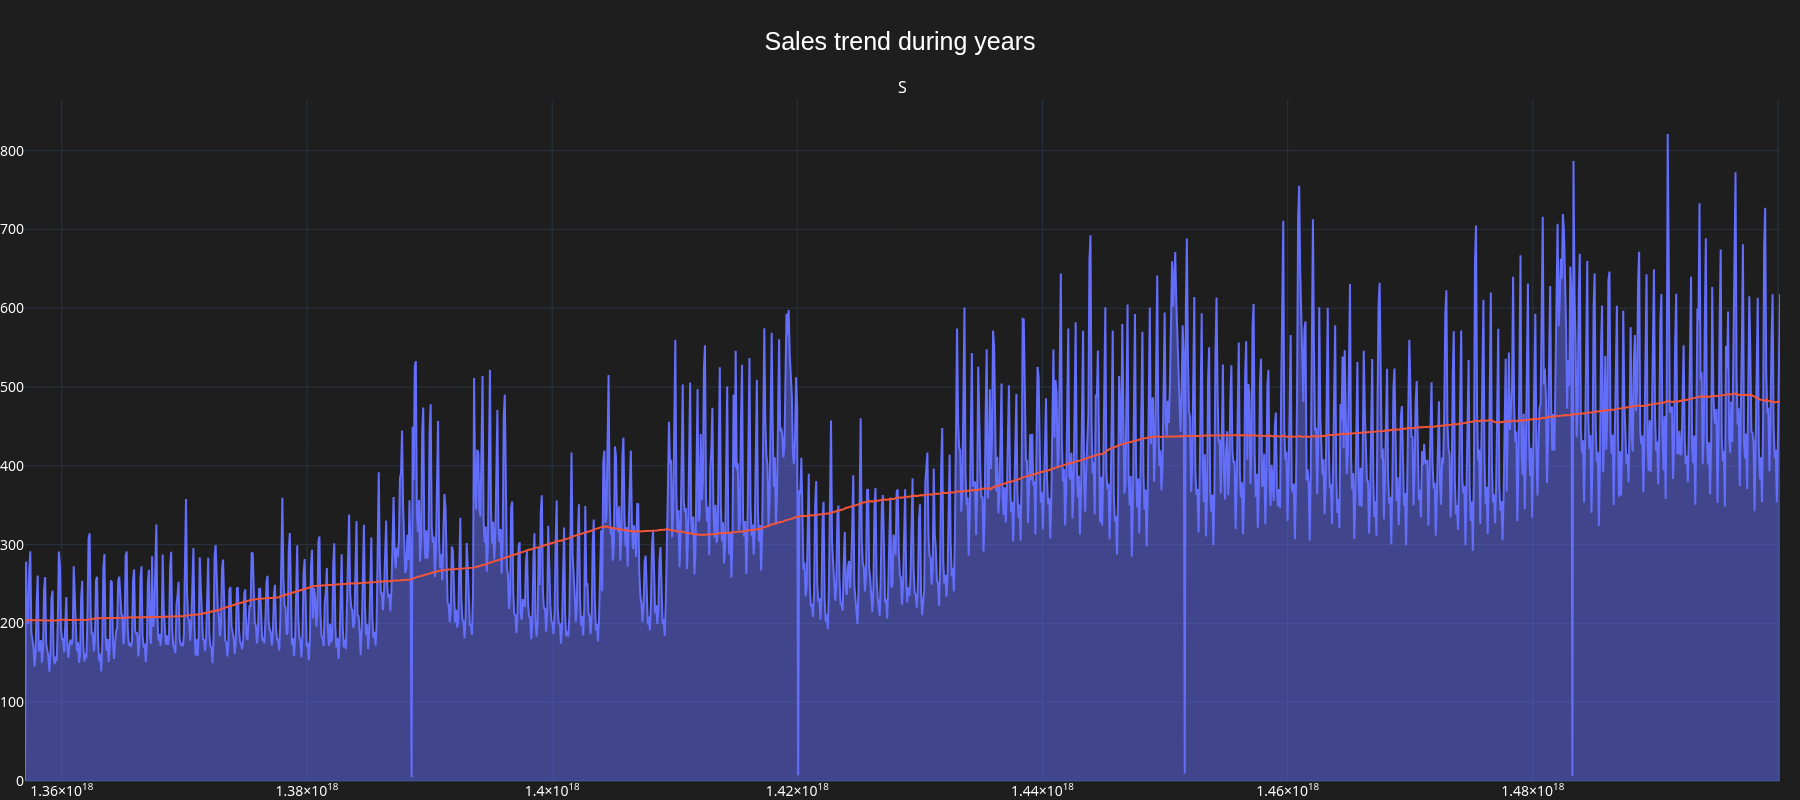

In [139]:
sales_during_year = sales[:train.shape[0]].groupby('date').agg({"sales" : "mean"}).reset_index()
sales_during_year.set_index('date',inplace=True)
moving_average = sales_during_year.rolling(
    window=365,       # 365-day window
    center=True,      # puts the average at the center of the window
    min_periods=183,  # choose about half the window size
).mean()              # compute the mean (could also do median, std, min, max, ...)
moving_average['date'] = sales_during_year.index

fig = make_subplots(rows=1, cols=1, vertical_spacing=0.08,                    
                    subplot_titles=("Sales 365 - Day Moving Average"))
fig.add_trace(go.Scatter(x=sales_during_year.index, y=sales_during_year['sales'],
                         mode='lines', fill='tozeroy',
                         name='365-Day Moving Average'))
fig.add_trace(go.Scatter(x=moving_average.date,y=moving_average.sales,mode='lines',name='Trend'))
fig.update_layout(height=350, bargap=0.15,
                  margin=dict(b=0,r=20,l=20), 
                  title_text="Sales trend during years",
                  template="plotly_dark",
                  title_font=dict(size=25, family="Lato, sans-serif"),
                  font=dict(color='white'),
                  hoverlabel=dict(font_size=13, font_family="Lato, sans-serif"),
                  showlegend=False)

fig.show()

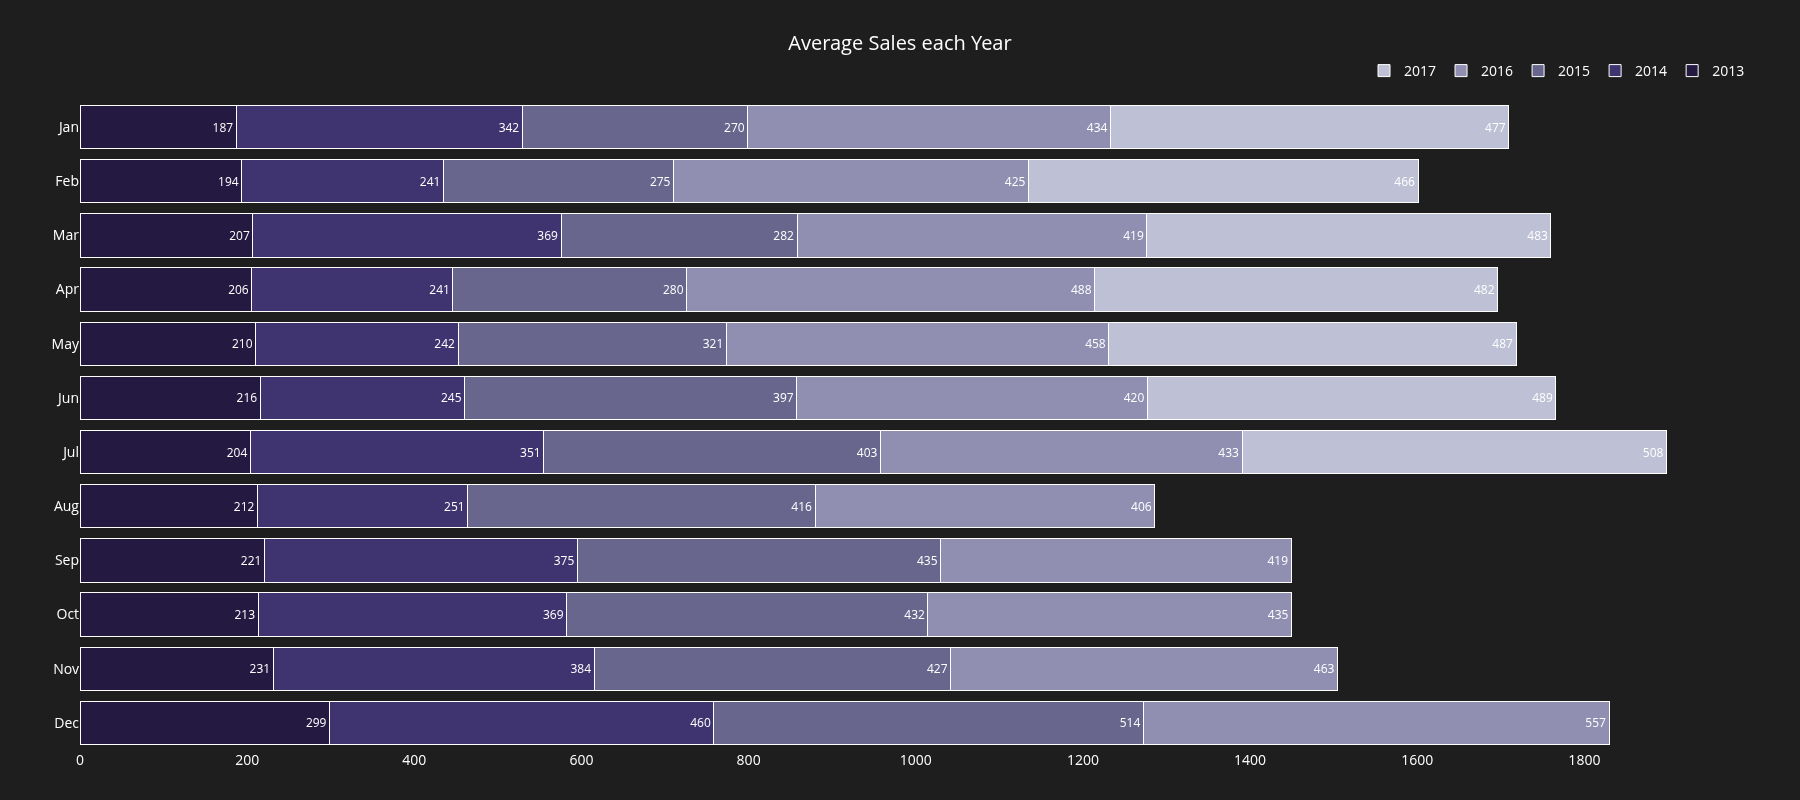

In [140]:
# Simplified data preparation - one line instead of 10+
sales_data = sales[:train.shape[0]].groupby(['year', 'month'])['sales'].mean().unstack(level=0).fillna(0)

# Setup
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = ['2013', '2014', '2015', '2016', '2017']
colors = ['rgba(38, 24, 74, 0.8)', 'rgba(71, 58, 131, 0.8)',
          'rgba(122, 120, 168, 0.8)', 'rgba(164, 163, 204, 0.85)',
          'rgba(190, 192, 213, 1)']

fig = go.Figure()

# Add bars for each year
for i, year in enumerate([2013, 2014, 2015, 2016, 2017]):
    if year in sales_data.columns:
        values = sales_data[year].values
    else:
        values = np.zeros(12)
    
    fig.add_trace(go.Bar(
        x=values, 
        y=months,
        orientation='h',
        name=years[i],
        marker=dict(color=colors[i], line=dict(color='white', width=1)),
        text=[f'{v:.0f}' if v > 0 else '' for v in values],  # Add values inside bars
        textposition='inside',
        textfont=dict(color='white', size=12)
    ))

fig.update_layout(
    title='Average Sales each Year',
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, categoryorder='array', categoryarray=months[::-1]),
    barmode='stack',
    template="plotly_dark",
    margin=dict(l=80, r=50, t=100, b=50),
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    font=dict(color='white'),
    height=600
)

fig.show()

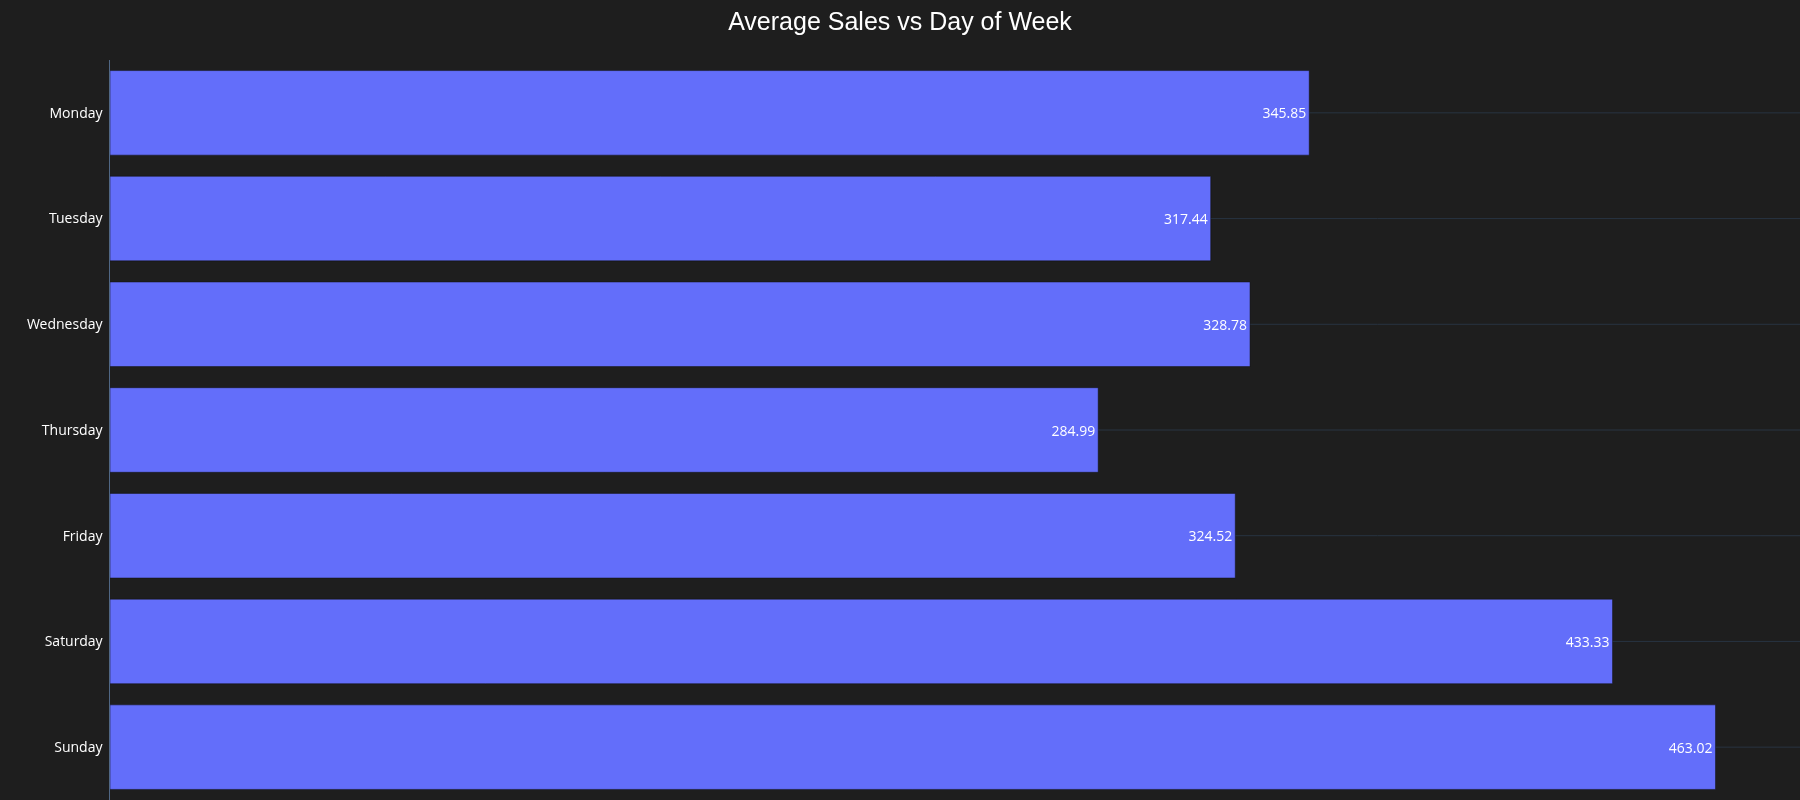

In [141]:
df_dw_sa = sales[:train.shape[0]].groupby('day_of_week').agg({"sales" : "mean"}).reset_index()
df_dw_sa.sales = round(df_dw_sa.sales, 2)

# chart
fig = px.bar(df_dw_sa, y='day_of_week', x='sales', title='Average Sales vs Day of Week',
             color_discrete_sequence=['dark blue'], text='sales',
             category_orders=dict(day_of_week=["Monday","Tuesday","Wednesday","Thursday", "Friday","Saturday","Sunday"]))
fig.update_yaxes(showgrid=True, ticksuffix=' ', showline=True)
fig.update_xaxes(visible=False)
fig.update_layout(margin=dict(t=60, b=0, l=0, r=0), height=350,
                  hovermode="y unified", 
                  yaxis_title=" ", template='plotly_dark',
                  title_font=dict(size=25, color='white', family="Lato, sans-serif"),
                  font=dict(color='white'),
                  hoverlabel=dict(bgcolor="#333333", font_size=13, font_family="Lato, sans-serif"))
fig.show()

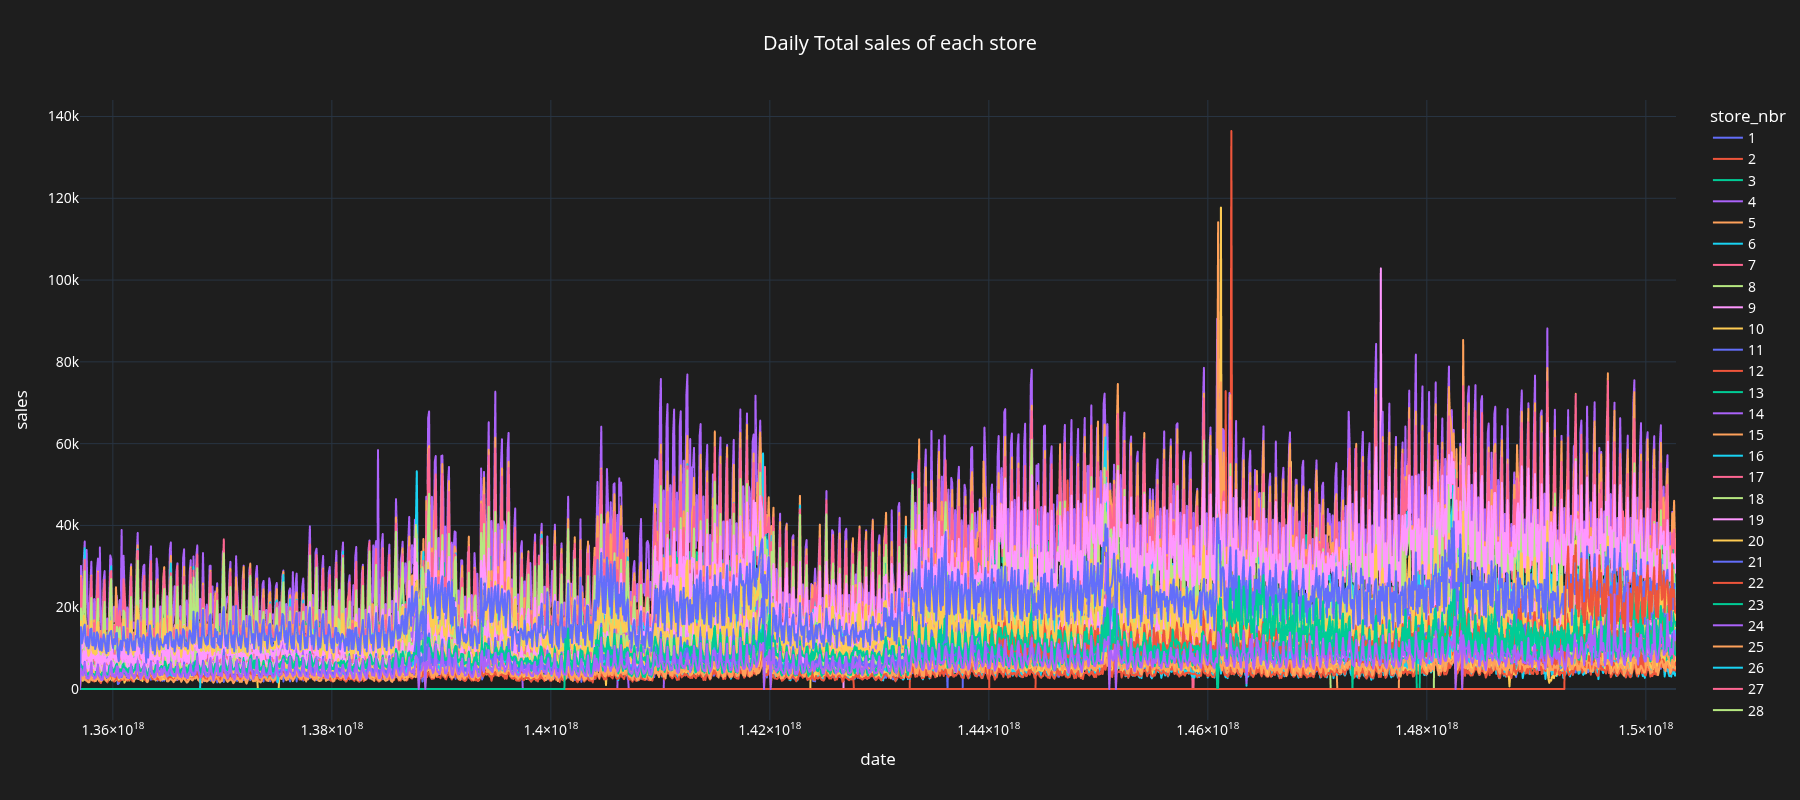

In [142]:
daily_total_sales = train.set_index('date').groupby('store_nbr').resample('D').sales.sum().reset_index()
fig = px.line(daily_total_sales,
        x='date', y='sales',
        color='store_nbr', title='Daily Total sales of each store',
        template='plotly_dark')
fig.show()

In [143]:
sales_per_store = daily_total_sales.groupby(['date', 'store_nbr']).agg({
    'sales':'sum'
})

sales_per_store

sales
date       store_nbr              
2013-01-01 1              0.000000
           2              0.000000
           3              0.000000
           4              0.000000
           5              0.000000
...                            ...
2017-08-15 50         16879.121004
           51         20154.559000
           52         18600.046000
           53          8208.189000
           54         12666.858000

[91152 rows x 1 columns]

In [144]:
store_with_no_sales = sales_per_store[sales_per_store.sales == 0]
store_with_no_sales

sales
date       store_nbr       
2013-01-01 1            0.0
           2            0.0
           3            0.0
           4            0.0
           5            0.0
...                     ...
2017-04-15 52           0.0
2017-04-16 52           0.0
2017-04-17 52           0.0
2017-04-18 52           0.0
2017-04-19 52           0.0

[7546 rows x 1 columns]

In [145]:
mask = ~train.set_index(['date', 'store_nbr']).index.isin(store_with_no_sales.index)
train_ = train[mask]

In [146]:
train_

,id,date,store_nbr,family,sales,onpromotion
561,561,2013-01-01,25,AUTOMOTIVE,0.000,0
562,562,2013-01-01,25,BABY CARE,0.000,0
563,563,2013-01-01,25,BEAUTY,2.000,0
564,564,2013-01-01,25,BEVERAGES,810.000,0
565,565,2013-01-01,25,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [147]:
# Verify: these store-date combinations should have total sales > 0
verification = train_.groupby(['date', 'store_nbr'])['sales'].sum()
print(f"Any zero total sales remaining: {(verification == 0).any()}")  # Should be False

# Compare row counts
print(f"Original rows: {len(train)}")
print(f"Filtered rows: {len(train_)}")
print(f"Removed rows: {len(train) - len(train_)}")

Any zero total sales remaining: False
Original rows: 3000888
Filtered rows: 2758998
Removed rows: 241890


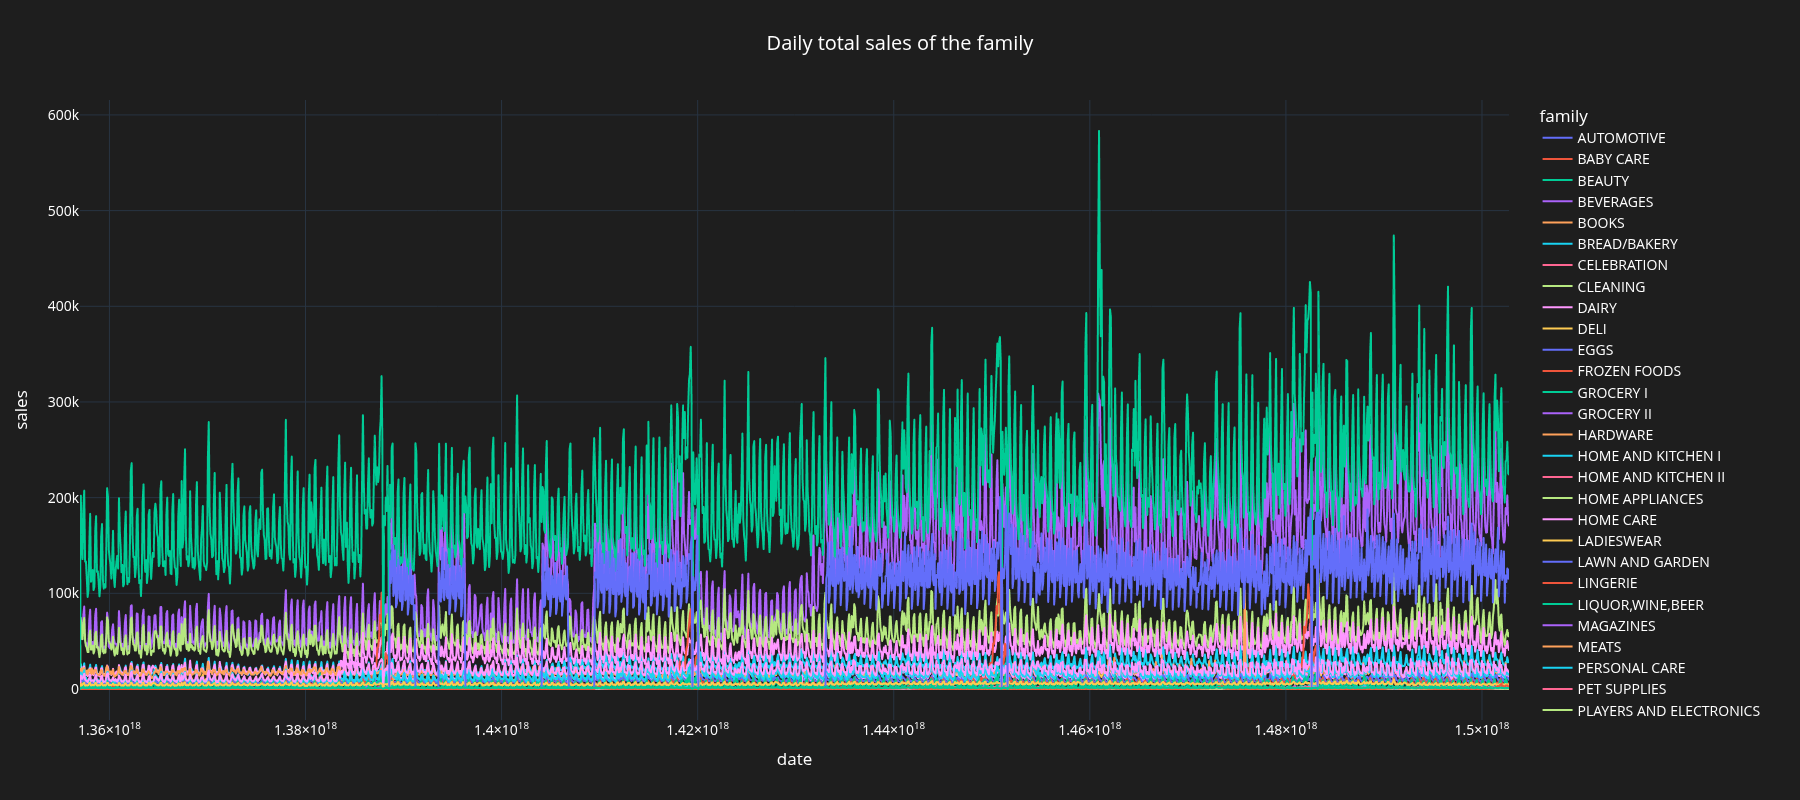

In [148]:
family_daily_total_sales = train_.set_index("date").groupby("family").resample("D").sales.sum().reset_index()
fig = px.line(family_daily_total_sales, x = "date", y= "sales", color = "family", title = "Daily total sales of the family", template='plotly_dark')
fig.show()

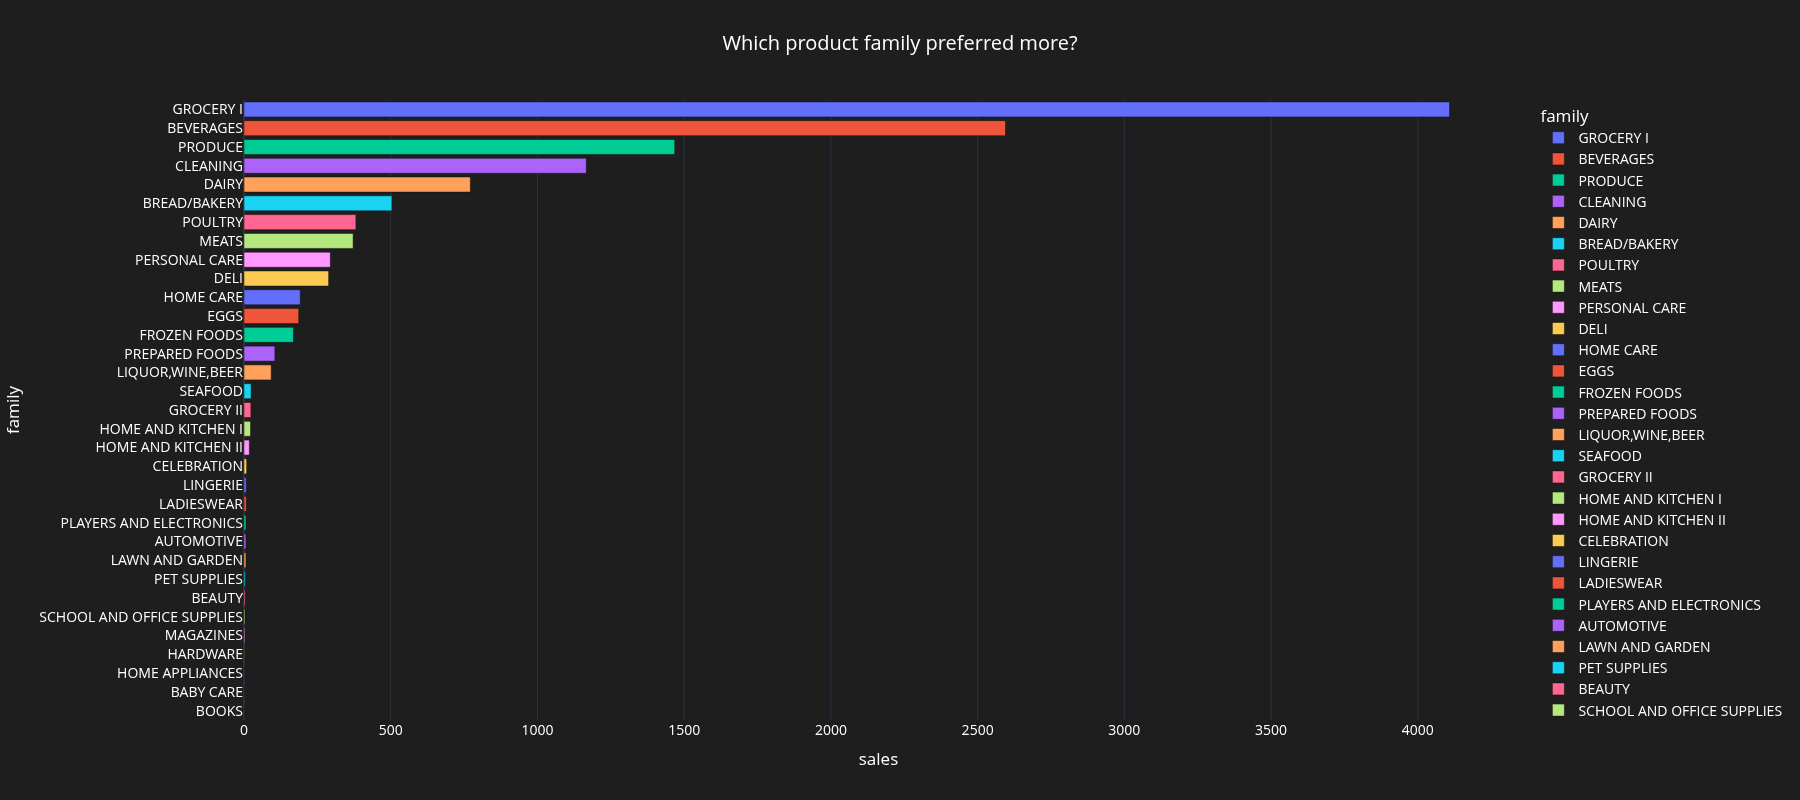

In [149]:
preferred_product = train_.groupby("family").sales.mean().sort_values(ascending = False).reset_index()
fig = px.bar(preferred_product, y = "family", x="sales",
       color = "family", title = "Which product family preferred more?",
       template='plotly_dark')
fig.show()

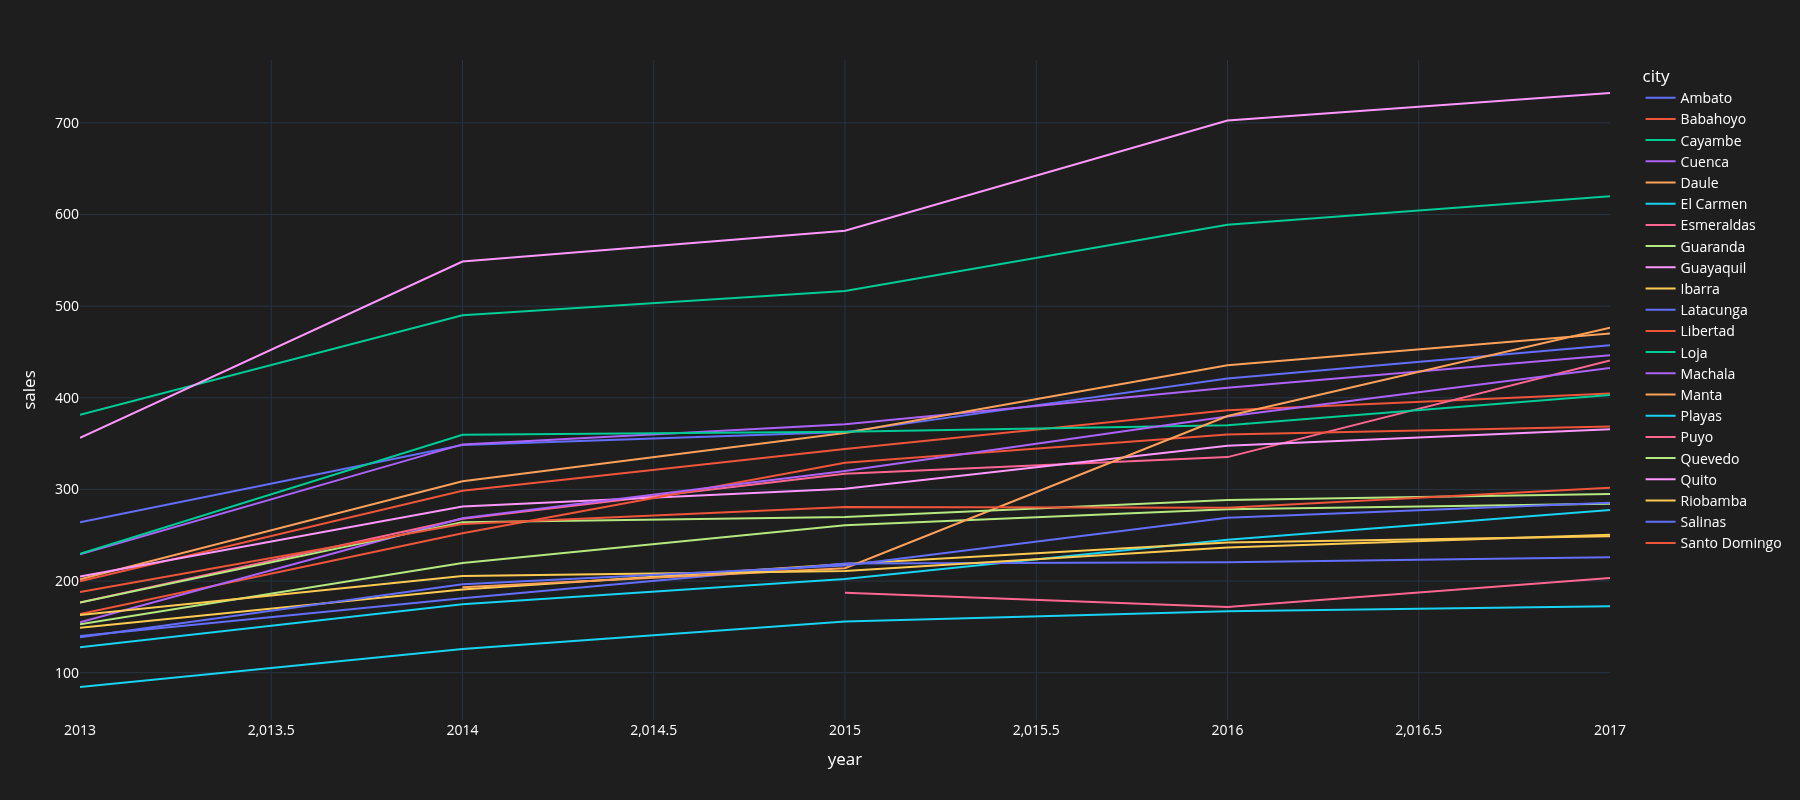

In [150]:
store_city = pd.merge(train_, stores)
store_city['year'] = store_city.date.dt.year
fig = px.line(store_city.groupby(["city", "year"]).sales.mean().reset_index(), x = "year", y = "sales",
        color = "city", template='plotly_dark')
fig.show()